#Load JSON Files

Loads the BloodHound dataset into Colab so the code can use it.

In [ ]:
import json

with open("users.json", "r") as f:
    users = json.load(f)

with open("groups.json", "r") as f:
    groups = json.load(f)

with open("computers.json", "r") as f:
    computers = json.load(f)

with open("domains.json", "r") as f:
    domains = json.load(f)

with open("containers.json", "r") as f:
    containers = json.load(f)

print("Files loaded successfully!")

Files loaded successfully!


#Inspect dataset

Checks what data is inside each file and how many users, groups, computers, and other objects there are.

In [ ]:
print("Users:", len(users["data"]))
print("Groups:", len(groups["data"]))
print("Computers:", len(computers["data"]))
print("Domains:", len(domains["data"]))
print("Containers:", len(containers["data"]))

Users: 53
Groups: 58
Computers: 1
Domains: 1
Containers: 206


#Explore ACE permissions

Shows the real permissions stored under RightName in the dataset.

In [ ]:
computer = computers["data"][0]

print("Computer Name:")
print(computer["Properties"]["name"])

print("\nPermissions:")
for ace in computer["Aces"]:
    print(
        ace["PrincipalType"],
        ace["PrincipalSID"],
        "->",
        ace["RightName"]
    )

Computer Name:
GHOST-DC01.GHOST.CORP

Permissions:
Group S-1-5-21-2845847946-3451170323-4261139666-512 -> Owns
Group S-1-5-21-2845847946-3451170323-4261139666-512 -> GenericAll
Group S-1-5-21-2697957641-2271029196-387917394-527 -> AddKeyCredentialLink
Base S-1-5-21-2845847946-3451170323-4261139666-526 -> AddKeyCredentialLink
Group S-1-5-21-2697957641-2271029196-387917394-519 -> GenericAll
Group GHOST.CORP-S-1-5-32-544 -> WriteDacl
Group GHOST.CORP-S-1-5-32-544 -> WriteOwner
Group GHOST.CORP-S-1-5-32-544 -> GenericWrite


#Build Synthetic Agents

Creates sample AI agents using identities and permissions from the BloodHound data.

In [ ]:
import json
from collections import defaultdict

direct_permissions = defaultdict(list)
inherited_permissions = defaultdict(list)

for obj in containers["data"]:
    resource = obj["Properties"]["name"]

    for ace in obj.get("Aces", []):
        principal_id = ace["PrincipalSID"]

        permission_entry = {
            "permission": ace["RightName"],
            "resource": resource
        }

        if ace["IsInherited"]:
            inherited_permissions[principal_id].append(permission_entry)
        else:
            direct_permissions[principal_id].append(permission_entry)


available_principals = sorted(
    set(direct_permissions.keys()) |
    set(inherited_permissions.keys())
)

number_of_agents = min(30, len(available_principals))


roles = {}
groups = {}
fake_agents = {}


for i, principal_id in enumerate(
    available_principals[:number_of_agents],
    start=1
):
    role_name = f"Agent_{i}_Inherited_Role"
    group_name = f"Agent_{i}_Inherited_Group"

    inherited_list = inherited_permissions.get(
        principal_id,
        []
    )

    direct_list = direct_permissions.get(
        principal_id,
        []
    )

    midpoint = len(inherited_list) // 2

    role_permissions = inherited_list[:midpoint]
    group_permissions = inherited_list[midpoint:]

    roles[role_name] = role_permissions
    groups[group_name] = group_permissions

    fake_agents[f"Agent_{i}"] = {
        "identity": f"Agent_{i}",
        "source_principal": principal_id,
        "roles": [role_name] if role_permissions else [],
        "groups": [group_name] if group_permissions else [],
        "direct_permissions": direct_list
    }


print("Agents created:", len(fake_agents))
print(json.dumps(fake_agents["Agent_1"], indent=2))

Agents created: 11
{
  "identity": "Agent_1",
  "source_principal": "GHOST.CORP-S-1-5-32-544",
  "roles": [
    "Agent_1_Inherited_Role"
  ],
  "groups": [
    "Agent_1_Inherited_Group"
  ],
  "direct_permissions": [
    {
      "permission": "WriteDacl",
      "resource": "ADMINSDHOLDER@GHOST.CORP"
    },
    {
      "permission": "WriteOwner",
      "resource": "ADMINSDHOLDER@GHOST.CORP"
    }
  ]
}


In [ ]:
print("FIRST AGENT:")
print(fake_agents["Agent_1"])

print("\nAGENT KEYS:")
print(fake_agents["Agent_1"].keys())

print("\nPOSSIBLE ROLE/GROUP VARIABLES:")
for variable_name, variable_value in globals().copy().items():
    lower_name = variable_name.lower()

    if any(
        term in lower_name
        for term in [
            "role",
            "group",
            "inherit",
            "permission",
            "membership"
        ]
    ):
        if isinstance(
            variable_value,
            (dict, list, set, tuple)
        ):
            try:
                print(
                    variable_name,
                    "| type:",
                    type(variable_value).__name__,
                    "| length:",
                    len(variable_value)
                )
            except Exception:
                print(
                    variable_name,
                    "| type:",
                    type(variable_value).__name__
                )

FIRST AGENT:
{'identity': 'Agent_1', 'source_principal': 'GHOST.CORP-S-1-5-32-544', 'roles': ['Agent_1_Inherited_Role'], 'groups': ['Agent_1_Inherited_Group'], 'direct_permissions': [{'permission': 'WriteDacl', 'resource': 'ADMINSDHOLDER@GHOST.CORP'}, {'permission': 'WriteOwner', 'resource': 'ADMINSDHOLDER@GHOST.CORP'}]}

AGENT KEYS:
dict_keys(['identity', 'source_principal', 'roles', 'groups', 'direct_permissions'])

POSSIBLE ROLE/GROUP VARIABLES:
groups | type: dict | length: 11
direct_permissions | type: defaultdict | length: 11
inherited_permissions | type: defaultdict | length: 4
permission_entry | type: dict | length: 2
roles | type: dict | length: 11
inherited_list | type: list | length: 0
role_permissions | type: list | length: 0
group_permissions | type: list | length: 0
role_permission_set | type: set | length: 0
group_permission_set | type: set | length: 0
inherited_permission_set | type: set | length: 0
all_direct_permission_pool | type: set | length: 610
all_inherited_perm

In [ ]:
print("FULL AGENT_1 STRUCTURE")
print("----------------------")

for key, value in fake_agents["Agent_1"].items():
    print(
        "\nKEY:",
        key
    )

    print(
        "TYPE:",
        type(value).__name__
    )

    print(
        "VALUE:",
        value
    )

FULL AGENT_1 STRUCTURE
----------------------

KEY: identity
TYPE: str
VALUE: Agent_1

KEY: source_principal
TYPE: str
VALUE: GHOST.CORP-S-1-5-32-544

KEY: roles
TYPE: list
VALUE: ['Agent_1_Inherited_Role']

KEY: groups
TYPE: list
VALUE: ['Agent_1_Inherited_Group']

KEY: direct_permissions
TYPE: list
VALUE: [{'permission': 'WriteDacl', 'resource': 'ADMINSDHOLDER@GHOST.CORP'}, {'permission': 'WriteOwner', 'resource': 'ADMINSDHOLDER@GHOST.CORP'}]


#Inspect Agent_1

Shows one sample agent, including its identity, roles, groups, and direct permissions.

In [ ]:
fake_agents["Agent_1"]

{'identity': 'Agent_1',
 'source_principal': 'GHOST.CORP-S-1-5-32-544',
 'roles': ['Agent_1_Inherited_Role'],
 'groups': ['Agent_1_Inherited_Group'],
 'direct_permissions': [{'permission': 'WriteDacl',
   'resource': 'ADMINSDHOLDER@GHOST.CORP'},
  {'permission': 'WriteOwner', 'resource': 'ADMINSDHOLDER@GHOST.CORP'}]}

#Overlap Engine

Compares direct permissions with role and group permissions to find access that is repeated or unnecessary.

In [ ]:
def to_permission_set(permission_list):
    return {
        (item["permission"], item["resource"])
        for item in permission_list
    }


def to_permission_dicts(permission_set):
    return [
        {
            "permission": permission,
            "resource": resource
        }
        for permission, resource in sorted(permission_set)
    ]


def analyze_overlap(agent, roles, groups):
    role_permissions = set()
    group_permissions = set()

    for role in agent["roles"]:
        role_permissions.update(
            to_permission_set(roles.get(role, []))
        )

    for group in agent["groups"]:
        group_permissions.update(
            to_permission_set(groups.get(group, []))
        )

    inherited_permissions = role_permissions.union(group_permissions)

    direct_permissions = to_permission_set(
        agent["direct_permissions"]
    )

    effective_permissions = inherited_permissions.union(
        direct_permissions
    )

    redundant_direct_permissions = direct_permissions.intersection(
        inherited_permissions
    )

    redundant_roles = []

    for role in agent["roles"]:
        role_perms = to_permission_set(
            roles.get(role, [])
        )

        other_inherited = set()

        for other_role in agent["roles"]:
            if other_role != role:
                other_inherited.update(
                    to_permission_set(
                        roles.get(other_role, [])
                    )
                )

        other_inherited.update(group_permissions)
        other_access = other_inherited.union(direct_permissions)

        if role_perms and role_perms.issubset(other_access):
            redundant_roles.append(role)

    redundant_groups = []

    for group in agent["groups"]:
        group_perms = to_permission_set(
            groups.get(group, [])
        )

        other_inherited = set()

        for other_group in agent["groups"]:
            if other_group != group:
                other_inherited.update(
                    to_permission_set(
                        groups.get(other_group, [])
                    )
                )

        other_inherited.update(role_permissions)
        other_access = other_inherited.union(direct_permissions)

        if group_perms and group_perms.issubset(other_access):
            redundant_groups.append(group)

    return {
        "identity": agent["identity"],
        "effective_permissions": to_permission_dicts(
            effective_permissions
        ),
        "redundant_direct_permissions": to_permission_dicts(
            redundant_direct_permissions
        ),
        "redundant_roles": redundant_roles,
        "redundant_groups": redundant_groups
    }


result = analyze_overlap(
    fake_agents["Agent_1"],
    roles,
    groups
)

print(json.dumps({
    "identity": result["identity"],
    "redundant_direct_permissions": result[
        "redundant_direct_permissions"
    ],
    "redundant_roles": result["redundant_roles"],
    "redundant_groups": result["redundant_groups"]
}, indent=2))

{
  "identity": "Agent_1",
  "redundant_direct_permissions": [],
  "redundant_roles": [],
  "redundant_groups": []
}


#Experiment 1 - Baseline Overlap Analysis

To what extent are agents’ direct permissions already covered by permissions inherited through existing roles or groups?

This measures how much permission overlap exists and whether agents could reuse existing group-based access instead of receiving separate direct permissions.

In [ ]:
import pandas as pd
import json

rq1_results = []

for agent_name, agent in fake_agents.items():
    overlap_result = analyze_overlap(agent, roles, groups)

    direct_count = len(
        to_permission_set(agent.get("direct_permissions", []))
    )

    role_permission_set = set()
    for role in agent.get("roles", []):
        role_permission_set.update(
            to_permission_set(roles.get(role, []))
        )

    group_permission_set = set()
    for group in agent.get("groups", []):
        group_permission_set.update(
            to_permission_set(groups.get(group, []))
        )

    inherited_permission_set = (
        role_permission_set | group_permission_set
    )

    redundant_direct_count = len(
        overlap_result["redundant_direct_permissions"]
    )

    overlap_percentage = (
        redundant_direct_count / direct_count * 100
        if direct_count > 0
        else 0
    )

    rq1_results.append({
        "agent": agent["identity"],
        "direct_permissions": direct_count,
        "inherited_permissions": len(inherited_permission_set),
        "redundant_direct_permissions": redundant_direct_count,
        "direct_permission_overlap_percent": round(
            overlap_percentage, 2
        ),
        "redundant_roles": len(
            overlap_result["redundant_roles"]
        ),
        "redundant_groups": len(
            overlap_result["redundant_groups"]
        )
    })

rq1_agent_results = pd.DataFrame(rq1_results)

print("RQ1 results by agent:")
print(rq1_agent_results.to_string(index=False))

RQ1 results by agent:
   agent  direct_permissions  inherited_permissions  redundant_direct_permissions  direct_permission_overlap_percent  redundant_roles  redundant_groups
 Agent_1                   2                     34                             0                               0.00                0                 0
 Agent_2                   3                      0                             0                               0.00                0                 0
 Agent_3                   3                    362                             2                              66.67                0                 0
 Agent_4                   1                      0                             0                               0.00                0                 0
 Agent_5                 546                    205                             5                               0.92                0                 0
 Agent_6                   1                      0               

In [ ]:
import pandas as pd

total_agents = len(rq1_agent_results)

total_direct_permissions = int(
    rq1_agent_results["direct_permissions"].sum()
)

total_inherited_permissions = int(
    rq1_agent_results["inherited_permissions"].sum()
)

total_redundant_direct = int(
    rq1_agent_results["redundant_direct_permissions"].sum()
)

agents_with_overlap = int(
    (
        rq1_agent_results["redundant_direct_permissions"] > 0
    ).sum()
)

overall_overlap_percentage = (
    total_redundant_direct / total_direct_permissions * 100
    if total_direct_permissions > 0
    else 0
)

agents_with_overlap_percentage = (
    agents_with_overlap / total_agents * 100
    if total_agents > 0
    else 0
)

total_redundant_roles = int(
    rq1_agent_results["redundant_roles"].sum()
)

total_redundant_groups = int(
    rq1_agent_results["redundant_groups"].sum()
)

rq1_summary = pd.DataFrame({
    "Metric": [
        "Agents analyzed",
        "Total direct permissions",
        "Total inherited permissions",
        "Redundant direct permissions",
        "Direct permissions covered by groups/roles (%)",
        "Agents with at least one overlapping permission",
        "Agents with overlap (%)",
        "Redundant roles",
        "Redundant groups"
    ],
    "Value": [
        f"{total_agents}",
        f"{total_direct_permissions}",
        f"{total_inherited_permissions}",
        f"{total_redundant_direct}",
        f"{overall_overlap_percentage:.2f}",
        f"{agents_with_overlap}",
        f"{agents_with_overlap_percentage:.2f}",
        f"{total_redundant_roles}",
        f"{total_redundant_groups}"
    ]
})

print("\nPart 1 Summary\n")
print(rq1_summary.to_string(index=False))


Part 1 Summary

                                         Metric Value
                                Agents analyzed    11
                       Total direct permissions   623
                    Total inherited permissions   604
                   Redundant direct permissions     7
 Direct permissions covered by groups/roles (%)  1.12
Agents with at least one overlapping permission     2
                        Agents with overlap (%) 18.18
                                Redundant roles     0
                               Redundant groups     0


In [ ]:
rq1_agent_results.to_csv(
    "rq1_overlap_by_agent.csv",
    index=False
)

rq1_summary.to_csv(
    "rq1_overlap_summary.csv",
    index=False
)

with open("rq1_overlap_results.json", "w") as f:
    json.dump(rq1_results, f, indent=2)

print("RQ1 results saved.")

RQ1 results saved.


#Experiment 2: Direct Permission Ratio VS Overlap

In [ ]:
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def normalize_permission(permission):
    if isinstance(permission, tuple):
        if len(permission) >= 2:
            return str(permission[0]), str(permission[1])

        if len(permission) == 1:
            return str(permission[0]), "UNKNOWN_RESOURCE"

    if isinstance(permission, dict):
        permission_name = (
            permission.get("RightName")
            or permission.get("right_name")
            or permission.get("permission")
            or permission.get("right")
            or permission.get("name")
            or "UNKNOWN_PERMISSION"
        )

        resource_name = (
            permission.get("Resource")
            or permission.get("resource")
            or permission.get("target")
            or permission.get("TargetName")
            or permission.get("ObjectName")
            or permission.get("PrincipalName")
            or permission.get("object_id")
            or permission.get("ObjectIdentifier")
            or "UNKNOWN_RESOURCE"
        )

        return str(permission_name), str(resource_name)

    if isinstance(permission, str):
        return permission, "UNKNOWN_RESOURCE"

    return str(permission), "UNKNOWN_RESOURCE"


def normalize_permission_collection(permission_collection):
    if permission_collection is None:
        return set()

    return {
        normalize_permission(permission)
        for permission in permission_collection
    }


def get_direct_permissions(agent):
    possible_keys = [
        "direct_permissions",
        "direct",
        "permissions",
        "DirectPermissions"
    ]

    for key in possible_keys:
        if key in agent:
            return normalize_permission_collection(agent[key])

    return set()


def get_inherited_permissions(agent):
    inherited_keys = [
        "inherited_permissions",
        "group_permissions",
        "role_permissions",
        "InheritedPermissions"
    ]

    for key in inherited_keys:
        if key in agent:
            return normalize_permission_collection(agent[key])

    inherited_permissions = set()

    roles = agent.get("roles", agent.get("inherited_roles", []))
    groups = agent.get("groups", agent.get("inherited_groups", []))

    if "to_permission_set" in globals():
        try:
            inherited_permissions.update(
                normalize_permission_collection(
                    to_permission_set(roles)
                )
            )
        except Exception:
            pass

        try:
            inherited_permissions.update(
                normalize_permission_collection(
                    to_permission_set(groups)
                )
            )
        except Exception:
            pass

    return inherited_permissions


if "synthetic_agents" in globals():
    source_agents = synthetic_agents

elif "fake_agents" in globals():
    source_agents = fake_agents

elif "agents" in globals():
    source_agents = agents

else:
    raise NameError(
        "No agent collection was found. Expected synthetic_agents, "
        "fake_agents, or agents."
    )


if isinstance(source_agents, dict):
    source_agent_items = list(source_agents.items())
else:
    source_agent_items = [
        (f"Agent_{index + 1}", agent)
        for index, agent in enumerate(source_agents)
    ]


standardized_agents = []

for agent_name, agent in source_agent_items:
    direct_permissions = get_direct_permissions(agent)
    inherited_permissions = get_inherited_permissions(agent)

    standardized_agents.append({
        "agent_id": str(agent_name),
        "direct_permissions": direct_permissions,
        "inherited_permissions": inherited_permissions
    })


print(f"Standardized agents: {len(standardized_agents)}")

for agent in standardized_agents[:3]:
    print(
        agent["agent_id"],
        "| Direct:", len(agent["direct_permissions"]),
        "| Inherited:", len(agent["inherited_permissions"])
    )


all_direct_permission_pool = set()
all_inherited_permission_pool = set()

for agent in standardized_agents:
    all_direct_permission_pool.update(
        agent["direct_permissions"]
    )

    all_inherited_permission_pool.update(
        agent["inherited_permissions"]
    )


all_permission_pool = (
    all_direct_permission_pool
    | all_inherited_permission_pool
)


print("\nPermission pool summary")
print("-----------------------")
print(
    "Unique direct permission-resource pairs:",
    len(all_direct_permission_pool)
)
print(
    "Unique inherited permission-resource pairs:",
    len(all_inherited_permission_pool)
)
print(
    "Unique permission-resource pairs overall:",
    len(all_permission_pool)
)


if len(all_permission_pool) == 0:
    raise ValueError(
        "The permission pool is empty. Check the names of the "
        "permission fields in your agent dictionaries."
    )

Standardized agents: 11
Agent_1 | Direct: 2 | Inherited: 0
Agent_2 | Direct: 3 | Inherited: 0
Agent_3 | Direct: 3 | Inherited: 0

Permission pool summary
-----------------------
Unique direct permission-resource pairs: 610
Unique inherited permission-resource pairs: 0
Unique permission-resource pairs overall: 610


In [ ]:
def calculate_overlap_metrics(
    direct_permissions,
    inherited_permissions
):
    direct_permissions = set(direct_permissions)
    inherited_permissions = set(inherited_permissions)

    overlapping_permissions = (
        direct_permissions
        & inherited_permissions
    )

    effective_permissions = (
        direct_permissions
        | inherited_permissions
    )

    direct_count = len(direct_permissions)
    inherited_count = len(inherited_permissions)
    effective_count = len(effective_permissions)
    overlap_count = len(overlapping_permissions)

    actual_direct_ratio = (
        direct_count / effective_count
        if effective_count > 0
        else 0.0
    )

    overlap_rate = (
        overlap_count / direct_count
        if direct_count > 0
        else 0.0
    )

    return {
        "direct_permission_count": direct_count,
        "inherited_permission_count": inherited_count,
        "effective_permission_count": effective_count,
        "overlap_count": overlap_count,
        "actual_direct_ratio": actual_direct_ratio,
        "overlap_rate": overlap_rate,
        "overlapping_permissions": overlapping_permissions
    }


def safe_sample(permission_pool, sample_size, rng):
    permission_pool = list(set(permission_pool))

    if sample_size <= 0:
        return set()

    if sample_size >= len(permission_pool):
        return set(permission_pool)

    return set(
        rng.sample(permission_pool, sample_size)
    )


def print_correlation_results(
    x_values,
    y_values,
    x_name
):
    clean_data = pd.DataFrame({
        "x": x_values,
        "y": y_values
    }).dropna()

    if len(clean_data) < 3:
        print(
            "Not enough observations to calculate correlations."
        )
        return None

    if clean_data["x"].nunique() < 2:
        print(f"{x_name} has no variation.")
        return None

    if clean_data["y"].nunique() < 2:
        print(
            "Overlap rate has no variation, so correlation "
            "is undefined."
        )
        return None

    pearson_r, pearson_p = pearsonr(
        clean_data["x"],
        clean_data["y"]
    )

    spearman_rho, spearman_p = spearmanr(
        clean_data["x"],
        clean_data["y"]
    )

    print(f"Pearson r: {pearson_r:.4f}")
    print(f"Pearson p-value: {pearson_p:.4f}")
    print(f"Spearman rho: {spearman_rho:.4f}")
    print(f"Spearman p-value: {spearman_p:.4f}")

    return {
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p
    }

In [ ]:
import random
import numpy as np
import pandas as pd

RANDOM_SEED = 101

TARGET_DIRECT_RATIOS = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

TARGET_OVERLAP_RATES = [
    0.00,
    0.02,
    0.05,
    0.10,
    0.15
]

AGENTS_PER_DIRECT_RATIO = 10


def generate_direct_ratio_agent(
    agent_id,
    target_direct_ratio,
    target_overlap_rate,
    permission_pool,
    rng
):
    total_permissions = 100

    direct_permission_count = round(
        total_permissions
        * target_direct_ratio
    )

    inherited_permission_count = (
        total_permissions
        - direct_permission_count
    )

    direct_permission_count = max(
        direct_permission_count,
        1
    )

    inherited_permission_count = max(
        inherited_permission_count,
        1
    )

    overlap_count = round(
        direct_permission_count
        * target_overlap_rate
    )

    overlap_count = min(
        overlap_count,
        direct_permission_count,
        inherited_permission_count
    )

    permission_pool = list(permission_pool)

    overlapping_permissions = set(
        rng.sample(
            permission_pool,
            overlap_count
        )
    )

    remaining_permissions = list(
        set(permission_pool)
        - overlapping_permissions
    )

    direct_unique = set(
        rng.sample(
            remaining_permissions,
            direct_permission_count
            - overlap_count
        )
    )

    remaining_permissions = list(
        set(remaining_permissions)
        - direct_unique
    )

    inherited_unique = set(
        rng.sample(
            remaining_permissions,
            inherited_permission_count
            - overlap_count
        )
    )

    direct_permissions = (
        direct_unique
        | overlapping_permissions
    )

    inherited_permissions = (
        inherited_unique
        | overlapping_permissions
    )

    metrics = calculate_overlap_metrics(
        direct_permissions,
        inherited_permissions
    )

    return {
        "agent_id": agent_id,
        "target_direct_ratio":
            target_direct_ratio,
        "assigned_target_overlap_rate":
            target_overlap_rate,
        **metrics
    }


experiment_1_rows = []

for ratio_index, target_ratio in enumerate(
    TARGET_DIRECT_RATIOS
):
    for overlap_index, target_overlap in enumerate(
        TARGET_OVERLAP_RATES
    ):
        for replicate in range(
            AGENTS_PER_DIRECT_RATIO
        ):
            local_rng = random.Random(
                RANDOM_SEED
                + ratio_index * 1000
                + overlap_index * 100
                + replicate
            )

            result = generate_direct_ratio_agent(
                agent_id=(
                    f"Ratio_{int(target_ratio*100):02d}"
                    f"_Overlap_{int(target_overlap*100):02d}"
                    f"_Agent_{replicate+1:02d}"
                ),
                target_direct_ratio=
                    target_ratio,
                target_overlap_rate=
                    target_overlap,
                permission_pool=
                    all_permission_pool,
                rng=local_rng
            )

            experiment_1_rows.append(result)


experiment_1_df = pd.DataFrame(
    experiment_1_rows
)

print(
    "Agents generated:",
    len(experiment_1_df)
)

display(
    experiment_1_df[
        [
            "agent_id",
            "target_direct_ratio",
            "assigned_target_overlap_rate",
            "actual_direct_ratio",
            "direct_permission_count",
            "inherited_permission_count",
            "overlap_count",
            "overlap_rate"
        ]
    ].head(20)
)

Agents generated: 450


,agent_id,target_direct_ratio,assigned_target_overlap_rate,actual_direct_ratio,direct_permission_count,inherited_permission_count,overlap_count,overlap_rate
0,Ratio_10_Overlap_00_Agent_01,0.1,0.00,0.1,10,90,0,0.0
1,Ratio_10_Overlap_00_Agent_02,0.1,0.00,0.1,10,90,0,0.0
2,Ratio_10_Overlap_00_Agent_03,0.1,0.00,0.1,10,90,0,0.0
3,Ratio_10_Overlap_00_Agent_04,0.1,0.00,0.1,10,90,0,0.0
4,Ratio_10_Overlap_00_Agent_05,0.1,0.00,0.1,10,90,0,0.0
5,Ratio_10_Overlap_00_Agent_06,0.1,0.00,0.1,10,90,0,0.0
6,Ratio_10_Overlap_00_Agent_07,0.1,0.00,0.1,10,90,0,0.0
7,Ratio_10_Overlap_00_Agent_08,0.1,0.00,0.1,10,90,0,0.0
8,Ratio_10_Overlap_00_Agent_09,0.1,0.00,0.1,10,90,0,0.0
9,Ratio_10_Overlap_00_Agent_10,0.1,0.00,0.1,10,90,0,0.0


In [ ]:
experiment_1_summary = (
    experiment_1_df
    .groupby("target_direct_ratio")
    .agg(
        agents=("agent_id", "count"),
        mean_actual_direct_ratio=(
            "actual_direct_ratio",
            "mean"
        ),
        mean_overlap_rate=(
            "overlap_rate",
            "mean"
        ),
        median_overlap_rate=(
            "overlap_rate",
            "median"
        ),
        std_overlap_rate=(
            "overlap_rate",
            "std"
        ),
        minimum_overlap_rate=(
            "overlap_rate",
            "min"
        ),
        maximum_overlap_rate=(
            "overlap_rate",
            "max"
        )
    )
    .reset_index()
)

display(experiment_1_summary)

print("\nOverall statistics")
print("------------------")
print("Agents:", len(experiment_1_df))
print(
    "Mean overlap rate:",
    f"{experiment_1_df['overlap_rate'].mean():.2%}"
)
print(
    "Median overlap rate:",
    f"{experiment_1_df['overlap_rate'].median():.2%}"
)
print(
    "Standard deviation:",
    f"{experiment_1_df['overlap_rate'].std():.2%}"
)
print(
    "Minimum overlap rate:",
    f"{experiment_1_df['overlap_rate'].min():.2%}"
)
print(
    "Maximum overlap rate:",
    f"{experiment_1_df['overlap_rate'].max():.2%}"
)

print(
    "\nCorrelation: direct ratio "
    "versus overlap rate"
)

experiment_1_correlations = (
    print_correlation_results(
        experiment_1_df[
            "actual_direct_ratio"
        ],
        experiment_1_df[
            "overlap_rate"
        ],
        "Actual direct-permission ratio"
    )
)

,target_direct_ratio,agents,mean_actual_direct_ratio,mean_overlap_rate,median_overlap_rate,std_overlap_rate,minimum_overlap_rate,maximum_overlap_rate
0,0.1,50,0.100610,0.060000,0.000000,0.080812,0.0,0.200000
1,0.2,50,0.202457,0.060000,0.050000,0.058902,0.0,0.150000
2,0.3,50,0.306186,0.066667,0.066667,0.047619,0.0,0.133333
3,0.4,50,0.410880,0.065000,0.050000,0.054398,0.0,0.150000
4,0.5,50,0.517010,0.064000,0.040000,0.059109,0.0,0.160000
5,0.6,50,0.624451,0.063333,0.050000,0.055737,0.0,0.150000
6,0.7,50,0.733341,0.062857,0.057143,0.053685,0.0,0.142857
7,0.8,50,0.845663,0.065000,0.050000,0.054398,0.0,0.150000
8,0.9,50,0.948976,0.055556,0.044444,0.043759,0.0,0.111111



Overall statistics
------------------
Agents: 450
Mean overlap rate: 6.25%
Median overlap rate: 5.00%
Standard deviation: 5.69%
Minimum overlap rate: 0.00%
Maximum overlap rate: 20.00%

Correlation: direct ratio versus overlap rate
Pearson r: 0.0500
Pearson p-value: 0.2902
Spearman rho: 0.1639
Spearman p-value: 0.0005


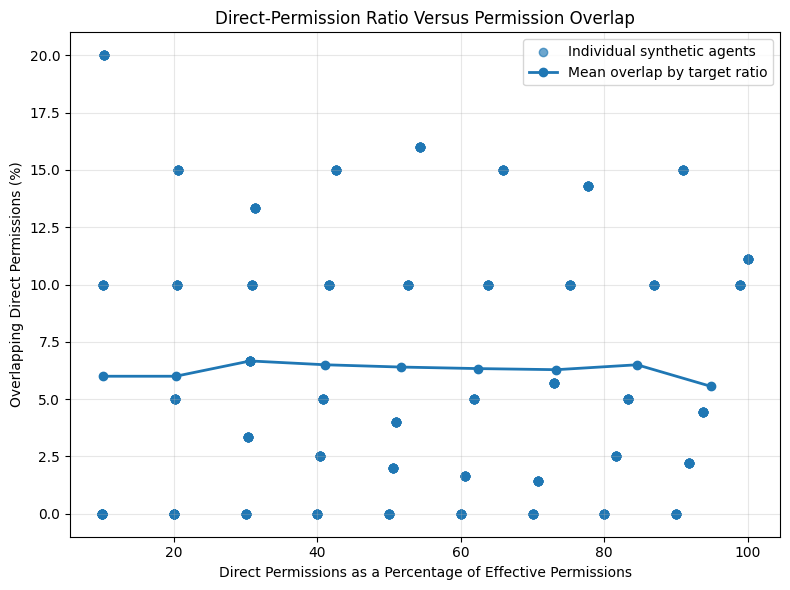

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    experiment_1_df[
        "actual_direct_ratio"
    ] * 100,
    experiment_1_df[
        "overlap_rate"
    ] * 100,
    alpha=0.65,
    label="Individual synthetic agents"
)

plt.plot(
    experiment_1_summary[
        "mean_actual_direct_ratio"
    ] * 100,
    experiment_1_summary[
        "mean_overlap_rate"
    ] * 100,
    marker="o",
    linewidth=2,
    label="Mean overlap by target ratio"
)

plt.xlabel(
    "Direct Permissions as a Percentage "
    "of Effective Permissions"
)
plt.ylabel(
    "Overlapping Direct Permissions (%)"
)
plt.title(
    "Direct-Permission Ratio Versus "
    "Permission Overlap"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#Experiment 3: Read/Write Mix VS Overlap

In [ ]:
unique_right_names = sorted({
    permission_name
    for permission_name, resource_name
    in all_permission_pool
})

print(
    "Unique RightName values found:",
    len(unique_right_names)
)

for right_name in unique_right_names:
    print(right_name)

Unique RightName values found: 4
GenericAll
Owns
WriteDacl
WriteOwner


In [ ]:
EXPLICIT_READ_RIGHTS = {
    "GenericRead",
    "ReadProperty",
    "ListChildren",
    "ReadLAPSPassword",
    "ReadGMSAPassword",
    "GetChanges",
    "GetChangesAll",
    "GetChangesInFilteredSet"
}

EXPLICIT_WRITE_RIGHTS = {
    "GenericWrite",
    "GenericAll",
    "WriteProperty",
    "WriteDacl",
    "WriteOwner",
    "Owns",
    "AddMember",
    "AddSelf",
    "ForceChangePassword",
    "AddKeyCredentialLink",
    "WriteSPN",
    "AddAllowedToAct",
    "AllowedToAct",
    "AddSIDHistory",
    "AllExtendedRights",
    "Enroll",
    "AutoEnroll",
    "ManageCA",
    "ManageCertificates",
    "GoldenCert",
    "DCSync"
}


def classify_right_name(right_name):
    right_name = str(right_name).strip()

    if right_name in EXPLICIT_READ_RIGHTS:
        return "read"

    if right_name in EXPLICIT_WRITE_RIGHTS:
        return "write"

    normalized = re.sub(
        r"[^a-z0-9]",
        "",
        right_name.lower()
    )

    read_patterns = [
        "read",
        "getchanges",
        "listchildren",
        "view",
        "query"
    ]

    write_patterns = [
        "write",
        "add",
        "remove",
        "delete",
        "modify",
        "change",
        "reset",
        "force",
        "owner",
        "dacl",
        "genericall",
        "extendedright",
        "enroll",
        "manage",
        "sync",
        "allowedtoact"
    ]

    if any(
        pattern in normalized
        for pattern in read_patterns
    ):
        return "read"

    if any(
        pattern in normalized
        for pattern in write_patterns
    ):
        return "write"

    return "other"


permission_classification_df = pd.DataFrame({
    "RightName": unique_right_names
})

permission_classification_df[
    "Classification"
] = (
    permission_classification_df[
        "RightName"
    ].apply(classify_right_name)
)

display(permission_classification_df)

print("\nClassification counts")
print("---------------------")
print(
    permission_classification_df[
        "Classification"
    ].value_counts()
)

,RightName,Classification
0,GenericAll,write
1,Owns,write
2,WriteDacl,write
3,WriteOwner,write



Classification counts
---------------------
Classification
write    4
Name: count, dtype: int64


In [ ]:
other_rights_df = (
    permission_classification_df[
        permission_classification_df[
            "Classification"
        ] == "other"
    ]
)

display(other_rights_df)

,RightName,Classification


In [ ]:
# Extract the permission name and resource safely regardless
# of which position they occupy in the tuple.

KNOWN_RIGHT_NAMES = {
    "GenericRead",
    "ReadProperty",
    "ListChildren",
    "ReadLAPSPassword",
    "ReadGMSAPassword",
    "GetChanges",
    "GetChangesAll",
    "GetChangesInFilteredSet",
    "GenericWrite",
    "GenericAll",
    "WriteProperty",
    "WriteDacl",
    "WriteOwner",
    "Owns",
    "AddMember",
    "AddSelf",
    "ForceChangePassword",
    "AddKeyCredentialLink",
    "WriteSPN",
    "AddAllowedToAct",
    "AllowedToAct",
    "AddSIDHistory",
    "AllExtendedRights",
    "Enroll",
    "AutoEnroll",
    "ManageCA",
    "ManageCertificates",
    "GoldenCert",
    "DCSync",
    "ExtendedRight"
}


def extract_right_and_resource(permission):
    if isinstance(permission, dict):
        right_name = (
            permission.get("RightName")
            or permission.get("right_name")
            or permission.get("permission")
            or permission.get("right")
            or permission.get("name")
            or "UNKNOWN_PERMISSION"
        )

        resource_name = (
            permission.get("Resource")
            or permission.get("resource")
            or permission.get("target")
            or permission.get("TargetName")
            or permission.get("ObjectName")
            or permission.get("ObjectIdentifier")
            or "UNKNOWN_RESOURCE"
        )

        return str(right_name), str(resource_name)

    if isinstance(permission, (tuple, list)):
        values = [str(value) for value in permission]

        for index, value in enumerate(values):
            if value in KNOWN_RIGHT_NAMES:
                other_values = [
                    item
                    for item_index, item in enumerate(values)
                    if item_index != index
                ]

                resource_name = (
                    other_values[0]
                    if other_values
                    else "UNKNOWN_RESOURCE"
                )

                return value, resource_name

        if len(values) >= 2:
            return values[0], values[1]

        if len(values) == 1:
            return values[0], "UNKNOWN_RESOURCE"

    return str(permission), "UNKNOWN_RESOURCE"


normalized_permission_pool = {
    extract_right_and_resource(permission)
    for permission in all_permission_pool
}


observed_read_permission_pool = {
    permission
    for permission in normalized_permission_pool
    if classify_right_name(permission[0]) == "read"
}

observed_write_permission_pool = {
    permission
    for permission in normalized_permission_pool
    if classify_right_name(permission[0]) == "write"
}

observed_other_permission_pool = {
    permission
    for permission in normalized_permission_pool
    if classify_right_name(permission[0]) == "other"
}


print(
    "Observed read permission-resource pairs:",
    len(observed_read_permission_pool)
)

print(
    "Observed write permission-resource pairs:",
    len(observed_write_permission_pool)
)

print(
    "Observed other permission-resource pairs:",
    len(observed_other_permission_pool)
)

Observed read permission-resource pairs: 0
Observed write permission-resource pairs: 610
Observed other permission-resource pairs: 0


In [ ]:
# BloodHound may contain no mundane read permissions because it is
# designed primarily for attack-path and privileged-access analysis.
#
# For the controlled read/write experiment, ordinary read operations
# are therefore attached to real resources from the dataset.

real_resources = sorted({
    resource
    for right_name, resource in normalized_permission_pool
    if resource != "UNKNOWN_RESOURCE"
})

if len(real_resources) == 0:
    raise ValueError(
        "No real BloodHound resources could be extracted."
    )


SYNTHETIC_READ_RIGHTS = [
    "ReadObject",
    "ReadProperties",
    "ListObject"
]


controlled_read_permission_pool = {
    (read_right, resource)
    for resource in real_resources
    for read_right in SYNTHETIC_READ_RIGHTS
}


# Use actual BloodHound write permissions.
controlled_write_permission_pool = set(
    observed_write_permission_pool
)


if len(controlled_write_permission_pool) == 0:
    raise ValueError(
        "No write permissions were found in the BloodHound dataset."
    )


# Balance the two pools so one permission category does not have
# a much larger candidate universe than the other category.

balanced_pool_size = min(
    len(controlled_read_permission_pool),
    len(controlled_write_permission_pool)
)

pool_rng = random.Random(42)

read_permission_pool = set(
    pool_rng.sample(
        list(controlled_read_permission_pool),
        balanced_pool_size
    )
)

write_permission_pool = set(
    pool_rng.sample(
        list(controlled_write_permission_pool),
        balanced_pool_size
    )
)


combined_read_write_pool = (
    read_permission_pool
    | write_permission_pool
)


print(
    "Controlled read permission-resource pairs:",
    len(read_permission_pool)
)

print(
    "Observed write permission-resource pairs used:",
    len(write_permission_pool)
)

print(
    "Combined balanced permission pool:",
    len(combined_read_write_pool)
)

print(
    "\nNote: Read operations are controlled synthetic permissions "
    "attached to real BloodHound resources."
)

Controlled read permission-resource pairs: 610
Observed write permission-resource pairs used: 610
Combined balanced permission pool: 1220

Note: Read operations are controlled synthetic permissions attached to real BloodHound resources.


In [ ]:
print("Sample read permissions:")

for permission in list(read_permission_pool)[:10]:
    print(permission)


print("\nSample write permissions:")

for permission in list(write_permission_pool)[:10]:
    print(permission)

Sample read permissions:
('ReadProperties', 'KRA@PHANTOM.CORP')
('ListObject', '2972D92D-A07A-44AC-9CB0-BF243356F345@PHANTOM.CORP')
('ReadProperties', 'CAA2BFAD-0CCA-483B-8D00-347F943292A8@PHANTOM.CORP')
('ListObject', '56040C71-FE93-4037-8FE9-1A4D1A283009@PHANTOM.CORP')
('ReadProperties', 'AIA@PHANTOM.CORP')
('ReadProperties', '94F238BF-831C-11D6-977B-00C04F613221@PHANTOM.CORP')
('ListObject', 'DEE21A17-4E8E-4F40-A58C-C0C009B685A7@PHANTOM.CORP')
('ListObject', '63C0F51A-067C-4640-8A4F-044FB33F1049@PHANTOM.CORP')
('ReadObject', '429A6334-1A00-4515-BF48-676DEB55954A@PHANTOM.CORP')
('ReadObject', 'DISPLAYSPECIFIERS@PHANTOM.CORP')

Sample write permissions:
('Owns', 'BBBB9DB0-4009-4368-8C40-6674E980D3C3@PHANTOM.CORP')
('Owns', 'CCFAE63A-7FB5-454C-83AB-0E8E1214974E@PHANTOM.CORP')
('WriteOwner', '73A9515B-511C-44D2-822B-444A33D3BD33@PHANTOM.CORP')
('Owns', '408@PHANTOM.CORP')
('WriteOwner', '429A6334-1A00-4515-BF48-676DEB55954A@PHANTOM.CORP')
('WriteDacl', 'A662B036-DBBE-4166-B4BA-21ABEA17F

In [ ]:
READ_WRITE_RANDOM_SEED = 202

TARGET_WRITE_RATIOS = [
    0.00,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.00
]

AGENTS_PER_WRITE_RATIO = 20


DIRECT_PERMISSIONS_PER_AGENT = min(
    30,
    len(read_permission_pool),
    len(write_permission_pool)
)


INHERITED_PERMISSIONS_PER_AGENT = min(
    50,
    len(combined_read_write_pool)
)


print(
    "Direct permissions per agent:",
    DIRECT_PERMISSIONS_PER_AGENT
)

print(
    "Inherited permissions per agent:",
    INHERITED_PERMISSIONS_PER_AGENT
)

print(
    "Agents per write ratio:",
    AGENTS_PER_WRITE_RATIO
)

print(
    "Total experimental agents:",
    len(TARGET_WRITE_RATIOS)
    * AGENTS_PER_WRITE_RATIO
)

Direct permissions per agent: 30
Inherited permissions per agent: 50
Agents per write ratio: 20
Total experimental agents: 220


In [ ]:
def generate_read_write_agent(
    agent_id,
    target_write_ratio,
    direct_permission_count,
    inherited_permission_count,
    read_pool,
    write_pool,
    combined_pool,
    rng
):
    read_pool = set(read_pool)
    write_pool = set(write_pool)
    combined_pool = set(combined_pool)

    target_write_count = round(
        direct_permission_count
        * target_write_ratio
    )

    target_read_count = (
        direct_permission_count
        - target_write_count
    )


    if target_write_count > len(write_pool):
        raise ValueError(
            "The requested write count is larger than the write pool."
        )

    if target_read_count > len(read_pool):
        raise ValueError(
            "The requested read count is larger than the read pool."
        )


    selected_write_permissions = safe_sample(
        write_pool,
        target_write_count,
        rng
    )

    selected_read_permissions = safe_sample(
        read_pool,
        target_read_count,
        rng
    )

    direct_permissions = (
        selected_read_permissions
        | selected_write_permissions
    )


    # Inherited permissions are sampled independently.
    # Overlap is therefore observed rather than manually assigned.

    inherited_permissions = safe_sample(
        combined_pool,
        inherited_permission_count,
        rng
    )


    actual_read_count = len(
        direct_permissions
        & read_pool
    )

    actual_write_count = len(
        direct_permissions
        & write_pool
    )

    classified_direct_count = (
        actual_read_count
        + actual_write_count
    )

    actual_write_ratio = (
        actual_write_count
        / classified_direct_count
        if classified_direct_count > 0
        else np.nan
    )


    metrics = calculate_overlap_metrics(
        direct_permissions,
        inherited_permissions
    )


    read_overlap_count = len(
        direct_permissions
        & inherited_permissions
        & read_pool
    )

    write_overlap_count = len(
        direct_permissions
        & inherited_permissions
        & write_pool
    )


    read_overlap_rate = (
        read_overlap_count / actual_read_count
        if actual_read_count > 0
        else np.nan
    )

    write_overlap_rate = (
        write_overlap_count / actual_write_count
        if actual_write_count > 0
        else np.nan
    )


    return {
        "agent_id": agent_id,
        "target_write_ratio": target_write_ratio,
        "actual_write_ratio": actual_write_ratio,
        "read_direct_count": actual_read_count,
        "write_direct_count": actual_write_count,
        "read_overlap_count": read_overlap_count,
        "write_overlap_count": write_overlap_count,
        "read_overlap_rate": read_overlap_rate,
        "write_overlap_rate": write_overlap_rate,
        **metrics
    }

In [ ]:
read_write_rows = []


for ratio_index, target_write_ratio in enumerate(
    TARGET_WRITE_RATIOS
):
    for replicate in range(
        AGENTS_PER_WRITE_RATIO
    ):
        local_seed = (
            READ_WRITE_RANDOM_SEED
            + ratio_index * 1000
            + replicate
        )

        local_rng = random.Random(local_seed)

        agent_id = (
            f"Write_{int(target_write_ratio * 100):03d}"
            f"_Agent_{replicate + 1:02d}"
        )

        result = generate_read_write_agent(
            agent_id=agent_id,
            target_write_ratio=target_write_ratio,
            direct_permission_count=(
                DIRECT_PERMISSIONS_PER_AGENT
            ),
            inherited_permission_count=(
                INHERITED_PERMISSIONS_PER_AGENT
            ),
            read_pool=read_permission_pool,
            write_pool=write_permission_pool,
            combined_pool=combined_read_write_pool,
            rng=local_rng
        )

        read_write_rows.append(result)


read_write_df = pd.DataFrame(
    read_write_rows
)


print(
    "Agents generated:",
    len(read_write_df)
)


display(
    read_write_df[
        [
            "agent_id",
            "target_write_ratio",
            "actual_write_ratio",
            "read_direct_count",
            "write_direct_count",
            "direct_permission_count",
            "inherited_permission_count",
            "overlap_count",
            "overlap_rate",
            "read_overlap_count",
            "write_overlap_count"
        ]
    ].head(20)
)

Agents generated: 220


,agent_id,target_write_ratio,actual_write_ratio,read_direct_count,write_direct_count,direct_permission_count,inherited_permission_count,overlap_count,overlap_rate,read_overlap_count,write_overlap_count
0,Write_000_Agent_01,0.0,0.0,30,0,30,50,1,0.033333,1,0
1,Write_000_Agent_02,0.0,0.0,30,0,30,50,2,0.066667,2,0
2,Write_000_Agent_03,0.0,0.0,30,0,30,50,1,0.033333,1,0
3,Write_000_Agent_04,0.0,0.0,30,0,30,50,0,0.000000,0,0
4,Write_000_Agent_05,0.0,0.0,30,0,30,50,1,0.033333,1,0
5,Write_000_Agent_06,0.0,0.0,30,0,30,50,3,0.100000,3,0
6,Write_000_Agent_07,0.0,0.0,30,0,30,50,3,0.100000,3,0
7,Write_000_Agent_08,0.0,0.0,30,0,30,50,2,0.066667,2,0
8,Write_000_Agent_09,0.0,0.0,30,0,30,50,2,0.066667,2,0
9,Write_000_Agent_10,0.0,0.0,30,0,30,50,0,0.000000,0,0


In [ ]:
ratio_validation_df = (
    read_write_df
    .groupby("target_write_ratio")
    .agg(
        agents=("agent_id", "count"),
        mean_actual_write_ratio=(
            "actual_write_ratio",
            "mean"
        ),
        minimum_actual_write_ratio=(
            "actual_write_ratio",
            "min"
        ),
        maximum_actual_write_ratio=(
            "actual_write_ratio",
            "max"
        ),
        mean_read_count=(
            "read_direct_count",
            "mean"
        ),
        mean_write_count=(
            "write_direct_count",
            "mean"
        )
    )
    .reset_index()
)


display(ratio_validation_df)

,target_write_ratio,agents,mean_actual_write_ratio,minimum_actual_write_ratio,maximum_actual_write_ratio,mean_read_count,mean_write_count
0,0.0,20,0.0,0.0,0.0,30.0,0.0
1,0.1,20,0.1,0.1,0.1,27.0,3.0
2,0.2,20,0.2,0.2,0.2,24.0,6.0
3,0.3,20,0.3,0.3,0.3,21.0,9.0
4,0.4,20,0.4,0.4,0.4,18.0,12.0
5,0.5,20,0.5,0.5,0.5,15.0,15.0
6,0.6,20,0.6,0.6,0.6,12.0,18.0
7,0.7,20,0.7,0.7,0.7,9.0,21.0
8,0.8,20,0.8,0.8,0.8,6.0,24.0
9,0.9,20,0.9,0.9,0.9,3.0,27.0


In [ ]:
read_write_valid_df = (
    read_write_df
    .dropna(
        subset=[
            "actual_write_ratio",
            "overlap_rate"
        ]
    )
    .copy()
)


read_write_summary = (
    read_write_valid_df
    .groupby("target_write_ratio")
    .agg(
        agents=("agent_id", "count"),
        mean_actual_write_ratio=(
            "actual_write_ratio",
            "mean"
        ),
        mean_overlap_rate=(
            "overlap_rate",
            "mean"
        ),
        median_overlap_rate=(
            "overlap_rate",
            "median"
        ),
        std_overlap_rate=(
            "overlap_rate",
            "std"
        ),
        minimum_overlap_rate=(
            "overlap_rate",
            "min"
        ),
        maximum_overlap_rate=(
            "overlap_rate",
            "max"
        ),
        mean_read_overlap_rate=(
            "read_overlap_rate",
            "mean"
        ),
        mean_write_overlap_rate=(
            "write_overlap_rate",
            "mean"
        )
    )
    .reset_index()
)


display(read_write_summary)

,target_write_ratio,agents,mean_actual_write_ratio,mean_overlap_rate,median_overlap_rate,std_overlap_rate,minimum_overlap_rate,maximum_overlap_rate,mean_read_overlap_rate,mean_write_overlap_rate
0,0.0,20,0.0,0.041667,0.033333,0.030349,0.0,0.100000,0.041667,NaN
1,0.1,20,0.1,0.035000,0.033333,0.035002,0.0,0.100000,0.031481,0.066667
2,0.2,20,0.2,0.036667,0.033333,0.032264,0.0,0.100000,0.041667,0.016667
3,0.3,20,0.3,0.038333,0.033333,0.027091,0.0,0.066667,0.042857,0.027778
4,0.4,20,0.4,0.046667,0.033333,0.039589,0.0,0.166667,0.050000,0.041667
5,0.5,20,0.5,0.040000,0.033333,0.036834,0.0,0.100000,0.046667,0.033333
6,0.6,20,0.6,0.065000,0.066667,0.042543,0.0,0.166667,0.066667,0.063889
7,0.7,20,0.7,0.043333,0.033333,0.039143,0.0,0.133333,0.061111,0.035714
8,0.8,20,0.8,0.050000,0.033333,0.039736,0.0,0.133333,0.025000,0.056250
9,0.9,20,0.9,0.040000,0.033333,0.031715,0.0,0.100000,0.000000,0.044444


In [ ]:
print("Read/write experiment statistics")
print("--------------------------------")

print(
    "Agents analyzed:",
    len(read_write_valid_df)
)

print(
    "Mean overlap rate:",
    f"{read_write_valid_df['overlap_rate'].mean():.2%}"
)

print(
    "Median overlap rate:",
    f"{read_write_valid_df['overlap_rate'].median():.2%}"
)

print(
    "Standard deviation:",
    f"{read_write_valid_df['overlap_rate'].std():.2%}"
)

print(
    "Minimum overlap rate:",
    f"{read_write_valid_df['overlap_rate'].min():.2%}"
)

print(
    "Maximum overlap rate:",
    f"{read_write_valid_df['overlap_rate'].max():.2%}"
)


print(
    "\nCorrelation between write-permission ratio "
    "and overlap rate"
)


read_write_correlations = print_correlation_results(
    read_write_valid_df[
        "actual_write_ratio"
    ],
    read_write_valid_df[
        "overlap_rate"
    ],
    "Actual write-permission ratio"
)

Read/write experiment statistics
--------------------------------
Agents analyzed: 220
Mean overlap rate: 4.32%
Median overlap rate: 3.33%
Standard deviation: 3.56%
Minimum overlap rate: 0.00%
Maximum overlap rate: 16.67%

Correlation between write-permission ratio and overlap rate
Pearson r: 0.0580
Pearson p-value: 0.3919
Spearman rho: 0.0481
Spearman p-value: 0.4775


In [ ]:
from scipy.stats import linregress


regression_result = linregress(
    read_write_valid_df[
        "actual_write_ratio"
    ],
    read_write_valid_df[
        "overlap_rate"
    ]
)


print(
    "Regression slope:",
    f"{regression_result.slope:.4f}"
)

print(
    "Regression intercept:",
    f"{regression_result.intercept:.4f}"
)

print(
    "Regression p-value:",
    f"{regression_result.pvalue:.4f}"
)

print(
    "Regression standard error:",
    f"{regression_result.stderr:.4f}"
)

print(
    "R-squared:",
    f"{regression_result.rvalue ** 2:.4f}"
)

Regression slope: 0.0065
Regression intercept: 0.0399
Regression p-value: 0.3919
Regression standard error: 0.0076
R-squared: 0.0034


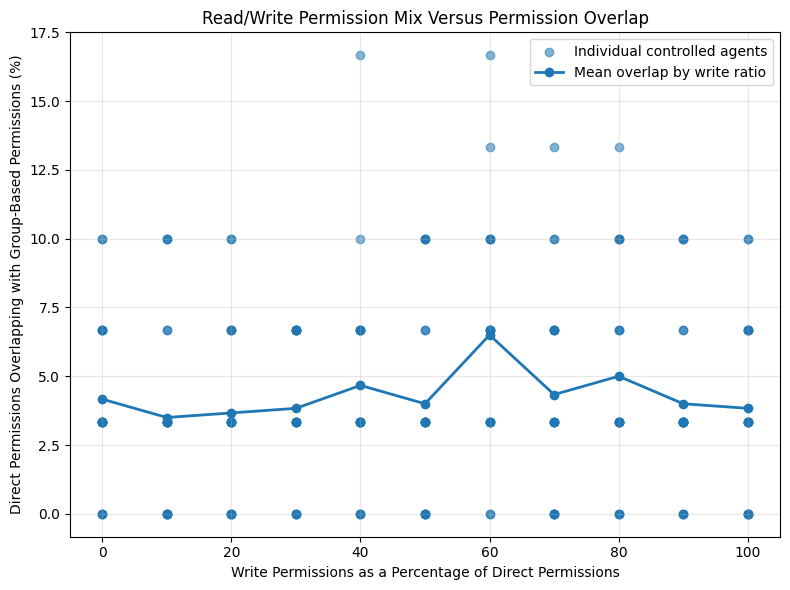

In [ ]:
plt.figure(figsize=(8, 6))


plt.scatter(
    read_write_valid_df[
        "actual_write_ratio"
    ] * 100,
    read_write_valid_df[
        "overlap_rate"
    ] * 100,
    alpha=0.55,
    label="Individual controlled agents"
)


plt.plot(
    read_write_summary[
        "mean_actual_write_ratio"
    ] * 100,
    read_write_summary[
        "mean_overlap_rate"
    ] * 100,
    marker="o",
    linewidth=2,
    label="Mean overlap by write ratio"
)


plt.xlabel(
    "Write Permissions as a Percentage "
    "of Direct Permissions"
)

plt.ylabel(
    "Direct Permissions Overlapping "
    "with Group-Based Permissions (%)"
)

plt.title(
    "Read/Write Permission Mix "
    "Versus Permission Overlap"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
read_write_type_summary = pd.DataFrame({
    "Permission type": [
        "Read",
        "Write"
    ],
    "Mean overlap rate": [
        read_write_valid_df[
            "read_overlap_rate"
        ].mean(),
        read_write_valid_df[
            "write_overlap_rate"
        ].mean()
    ],
    "Median overlap rate": [
        read_write_valid_df[
            "read_overlap_rate"
        ].median(),
        read_write_valid_df[
            "write_overlap_rate"
        ].median()
    ]
})


display(read_write_type_summary)

,Permission type,Mean overlap rate,Median overlap rate
0,Read,0.040712,0.0
1,Write,0.042474,0.0


In [ ]:
read_write_df.drop(
    columns=[
        "overlapping_permissions"
    ],
    errors="ignore"
).to_csv(
    "read_write_ratio_results.csv",
    index=False
)


read_write_summary.to_csv(
    "read_write_ratio_summary.csv",
    index=False
)


ratio_validation_df.to_csv(
    "read_write_ratio_validation.csv",
    index=False
)


read_write_type_summary.to_csv(
    "read_write_type_comparison.csv",
    index=False
)


print(
    "Read/write experiment results exported successfully."
)

Read/write experiment results exported successfully.


#Combined Results Summary (Experiments 1-3)

In [ ]:
def format_correlation_value(results, key):
    if results is None:
        return "Undefined"

    value = results.get(key)

    if value is None or pd.isna(value):
        return "Undefined"

    return f"{value:.4f}"


baseline_agents = 11
baseline_direct_permissions = 623
baseline_inherited_permissions = 604
baseline_overlap_count = 7
baseline_overlap_rate = (
    baseline_overlap_count
    / baseline_direct_permissions
)


combined_results_data = [
    {
        "Analysis": "Baseline permission overlap",
        "Independent Variable": "Original synthetic agents",
        "Agents Analyzed": baseline_agents,
        "Direct Permissions": baseline_direct_permissions,
        "Inherited Permissions": baseline_inherited_permissions,
        "Overlapping Permissions": baseline_overlap_count,
        "Mean Overlap Rate": f"{baseline_overlap_rate:.2%}",
        "Median Overlap Rate": "Not applicable",
        "Minimum Overlap Rate": "Not applicable",
        "Maximum Overlap Rate": "Not applicable",
        "Pearson Correlation": "Not applicable",
        "Pearson p-value": "Not applicable",
        "Spearman Correlation": "Not applicable",
        "Spearman p-value": "Not applicable"
    },
    {
        "Analysis": "Direct-permission ratio vs. overlap",
        "Independent Variable": "Direct-permission ratio",
        "Agents Analyzed": len(experiment_1_df),
        "Direct Permissions": int(
            experiment_1_df[
                "direct_permission_count"
            ].sum()
        ),
        "Inherited Permissions": int(
            experiment_1_df[
                "inherited_permission_count"
            ].sum()
        ),
        "Overlapping Permissions": int(
            experiment_1_df[
                "overlap_count"
            ].sum()
        ),
        "Mean Overlap Rate": (
            f"{experiment_1_df['overlap_rate'].mean():.2%}"
        ),
        "Median Overlap Rate": (
            f"{experiment_1_df['overlap_rate'].median():.2%}"
        ),
        "Minimum Overlap Rate": (
            f"{experiment_1_df['overlap_rate'].min():.2%}"
        ),
        "Maximum Overlap Rate": (
            f"{experiment_1_df['overlap_rate'].max():.2%}"
        ),
        "Pearson Correlation": format_correlation_value(
            experiment_1_correlations,
            "pearson_r"
        ),
        "Pearson p-value": format_correlation_value(
            experiment_1_correlations,
            "pearson_p"
        ),
        "Spearman Correlation": format_correlation_value(
            experiment_1_correlations,
            "spearman_rho"
        ),
        "Spearman p-value": format_correlation_value(
            experiment_1_correlations,
            "spearman_p"
        )
    },
    {
        "Analysis": "Read/write mix vs. overlap",
        "Independent Variable": "Write-permission ratio",
        "Agents Analyzed": len(read_write_valid_df),
        "Direct Permissions": int(
            read_write_valid_df[
                "direct_permission_count"
            ].sum()
        ),
        "Inherited Permissions": int(
            read_write_valid_df[
                "inherited_permission_count"
            ].sum()
        ),
        "Overlapping Permissions": int(
            read_write_valid_df[
                "overlap_count"
            ].sum()
        ),
        "Mean Overlap Rate": (
            f"{read_write_valid_df['overlap_rate'].mean():.2%}"
        ),
        "Median Overlap Rate": (
            f"{read_write_valid_df['overlap_rate'].median():.2%}"
        ),
        "Minimum Overlap Rate": (
            f"{read_write_valid_df['overlap_rate'].min():.2%}"
        ),
        "Maximum Overlap Rate": (
            f"{read_write_valid_df['overlap_rate'].max():.2%}"
        ),
        "Pearson Correlation": format_correlation_value(
            read_write_correlations,
            "pearson_r"
        ),
        "Pearson p-value": format_correlation_value(
            read_write_correlations,
            "pearson_p"
        ),
        "Spearman Correlation": format_correlation_value(
            read_write_correlations,
            "spearman_rho"
        ),
        "Spearman p-value": format_correlation_value(
            read_write_correlations,
            "spearman_p"
        )
    }
]


combined_results_df = pd.DataFrame(
    combined_results_data
)


display(combined_results_df)

,Analysis,Independent Variable,Agents Analyzed,Direct Permissions,Inherited Permissions,Overlapping Permissions,Mean Overlap Rate,Median Overlap Rate,Minimum Overlap Rate,Maximum Overlap Rate,Pearson Correlation,Pearson p-value,Spearman Correlation,Spearman p-value
0,Baseline permission overlap,Original synthetic agents,11,623,604,7,1.12%,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable
1,Direct-permission ratio vs. overlap,Direct-permission ratio,450,22500,22500,1400,6.25%,5.00%,0.00%,20.00%,0.0500,0.2902,0.1639,0.0005
2,Read/write mix vs. overlap,Write-permission ratio,220,6600,11000,285,4.32%,3.33%,0.00%,16.67%,0.0580,0.3919,0.0481,0.4775


In [ ]:
print("COMBINED PERMISSION OVERLAP RESULTS")
print("=" * 45)


print("\nBaseline analysis")
print("-----------------")
print(
    f"Agents analyzed: {baseline_agents}"
)
print(
    f"Direct permissions: {baseline_direct_permissions}"
)
print(
    f"Inherited permissions: {baseline_inherited_permissions}"
)
print(
    f"Overlapping permissions: {baseline_overlap_count}"
)
print(
    f"Overall overlap rate: {baseline_overlap_rate:.2%}"
)


print("\nDirect-permission ratio analysis")
print("--------------------------------")
print(
    f"Agents analyzed: {len(experiment_1_df)}"
)
print(
    "Mean overlap rate:",
    f"{experiment_1_df['overlap_rate'].mean():.2%}"
)
print(
    "Median overlap rate:",
    f"{experiment_1_df['overlap_rate'].median():.2%}"
)
print(
    "Pearson correlation:",
    format_correlation_value(
        experiment_1_correlations,
        "pearson_r"
    )
)
print(
    "Pearson p-value:",
    format_correlation_value(
        experiment_1_correlations,
        "pearson_p"
    )
)
print(
    "Spearman correlation:",
    format_correlation_value(
        experiment_1_correlations,
        "spearman_rho"
    )
)
print(
    "Spearman p-value:",
    format_correlation_value(
        experiment_1_correlations,
        "spearman_p"
    )
)


print("\nRead/write permission mix analysis")
print("----------------------------------")
print(
    f"Agents analyzed: {len(read_write_valid_df)}"
)
print(
    "Mean overlap rate:",
    f"{read_write_valid_df['overlap_rate'].mean():.2%}"
)
print(
    "Median overlap rate:",
    f"{read_write_valid_df['overlap_rate'].median():.2%}"
)
print(
    "Pearson correlation:",
    format_correlation_value(
        read_write_correlations,
        "pearson_r"
    )
)
print(
    "Pearson p-value:",
    format_correlation_value(
        read_write_correlations,
        "pearson_p"
    )
)
print(
    "Spearman correlation:",
    format_correlation_value(
        read_write_correlations,
        "spearman_rho"
    )
)
print(
    "Spearman p-value:",
    format_correlation_value(
        read_write_correlations,
        "spearman_p"
    )
)

COMBINED PERMISSION OVERLAP RESULTS

Baseline analysis
-----------------
Agents analyzed: 11
Direct permissions: 623
Inherited permissions: 604
Overlapping permissions: 7
Overall overlap rate: 1.12%

Direct-permission ratio analysis
--------------------------------
Agents analyzed: 450
Mean overlap rate: 6.25%
Median overlap rate: 5.00%
Pearson correlation: 0.0500
Pearson p-value: 0.2902
Spearman correlation: 0.1639
Spearman p-value: 0.0005

Read/write permission mix analysis
----------------------------------
Agents analyzed: 220
Mean overlap rate: 4.32%
Median overlap rate: 3.33%
Pearson correlation: 0.0580
Pearson p-value: 0.3919
Spearman correlation: 0.0481
Spearman p-value: 0.4775


In [ ]:
combined_results_df.to_csv(
    "combined_permission_overlap_results.csv",
    index=False
)

print(
    "Combined results exported to "
    "combined_permission_overlap_results.csv"
)

Combined results exported to combined_permission_overlap_results.csv


#Policy Creator

Turns a normal English request into a simple policy with an identity and allow or deny rules.

In [ ]:
import re

permission_names = [
    "Owns",
    "WriteDacl",
    "WriteOwner",
    "GenericAll",
    "GenericWrite",
    "AllExtendedRights",
    "GetChanges",
    "GetChangesAll",
    "GetChangesInFilteredSet",
    "AddKeyCredentialLink"
]


def create_policy_from_nl(nl_request):
    identity_match = re.search(
        r"(?:the\s+)?(.+?\s+Agent)",
        nl_request,
        re.IGNORECASE
    )

    if not identity_match:
        raise ValueError("Could not find an agent identity.")

    identity = identity_match.group(1).strip().replace(" ", "_")
    rules = []

    lines = nl_request.strip().splitlines()

    for line in lines:
        line = line.strip()

        if not line:
            continue

        matched_permission = None

        for permission in permission_names:
            if re.search(
                rf"\b{re.escape(permission)}\b",
                line,
                re.IGNORECASE
            ):
                matched_permission = permission
                break

        if not matched_permission:
            continue

        if " on " not in line.lower():
            continue

        resource = re.split(
            r"\s+on\s+",
            line,
            maxsplit=1,
            flags=re.IGNORECASE
        )[1].strip()

        resource = resource.rstrip(".")

        deny_phrases = [
            "not allowed",
            "should not",
            "cannot",
            "can't",
            "deny"
        ]

        is_deny = any(
            phrase in line.lower()
            for phrase in deny_phrases
        )

        effect = "Deny" if is_deny else "Allow"

        rules.append(
            f"{effect}: {matched_permission} on {resource}"
        )

    if not rules:
        raise ValueError("No valid permission rules were found.")

    return f"Identity: {identity}\n" + "\n".join(rules)

In [ ]:
nl_request = """
The Database Agent should be able to WriteDacl on USERS@GHOST.CORP,
but it should not be allowed to Owns on USERS@GHOST.CORP.
"""

created_policy = create_policy_from_nl(nl_request)

print(created_policy)

Identity: Database_Agent
Allow: WriteDacl on USERS@GHOST.CORP,
Deny: Owns on USERS@GHOST.CORP


#Policy Parser

Changes the policy text into JSON so the computer can read it.

In [ ]:
import json

def parse_policy(policy_text):
    policies = []
    current_policy = None

    lines = policy_text.strip().split("\n")

    for line in lines:
        line = line.strip()

        if not line:
            continue

        if line.startswith("Identity:"):
            if current_policy is not None:
                policies.append(current_policy)

            current_policy = {
                "identity": line.replace("Identity:", "").strip(),
                "allow": [],
                "deny": []
            }

        elif line.startswith("Allow:"):
            rule = line.replace("Allow:", "").strip()

            if " on " not in rule:
                continue

            action, resource = rule.split(" on ", 1)

            current_policy["allow"].append({
                "action": action.strip(),
                "resource": resource.strip()
            })

        elif line.startswith("Deny:"):
            rule = line.replace("Deny:", "").strip()

            if " on " not in rule:
                continue

            action, resource = rule.split(" on ", 1)

            current_policy["deny"].append({
                "action": action.strip(),
                "resource": resource.strip()
            })

    if current_policy is not None:
        policies.append(current_policy)

    return policies


parsed_policies = parse_policy(created_policy)

print(json.dumps(parsed_policies, indent=2))

[
  {
    "identity": "Database_Agent",
    "allow": [
      {
        "action": "WriteDacl",
        "resource": "USERS@GHOST.CORP,"
      }
    ],
    "deny": [
      {
        "action": "Owns",
        "resource": "USERS@GHOST.CORP"
      }
    ]
  }
]


#Experiment 4 - Policy Translation Evaluation

How accurately can natural-language permission requests be translated into structured agent policies?

This measures whether the Policy Creator correctly extracts the agent identity, permission, resource, and allow/deny decision from normal English.

In [ ]:
import random

random.seed(42)

permission_resource_pairs = set()

all_files = [users, groups, computers, domains, containers]

for dataset in all_files:
    for obj in dataset.get("data", []):
        resource = obj.get("Properties", {}).get("name")

        if not resource:
            continue

        for ace in obj.get("Aces", []):
            permission = ace.get("RightName")

            if permission:
                permission_resource_pairs.add(
                    (permission, resource)
                )

permission_resource_pairs = list(
    permission_resource_pairs
)

print(
    "Unique permission-resource pairs found:",
    len(permission_resource_pairs)
)

Unique permission-resource pairs found: 1138


In [ ]:
agent_names = [
    "Database Agent",
    "Security Agent",
    "Monitoring Agent",
    "Access Agent",
    "Policy Agent",
    "Infrastructure Agent",
    "Directory Agent",
    "Audit Agent"
]

allow_templates = [
    "The {agent} should be able to {permission} on {resource}.",
    "The {agent} can {permission} on {resource}.",
    "Allow the {agent} to {permission} on {resource}.",
    "The {agent} may {permission} on {resource}."
]

deny_templates = [
    "The {agent} should not be allowed to {permission} on {resource}.",
    "The {agent} cannot {permission} on {resource}.",
    "Deny the {agent} from using {permission} on {resource}.",
    "The {agent} must not {permission} on {resource}."
]

selected_pairs = random.sample(
    permission_resource_pairs,
    min(30, len(permission_resource_pairs))
)

rq2_test_cases = []

for index, (permission, resource) in enumerate(
    selected_pairs
):
    agent = agent_names[
        index % len(agent_names)
    ]

    is_allow = index % 2 == 0

    if is_allow:
        request = random.choice(
            allow_templates
        ).format(
            agent=agent,
            permission=permission,
            resource=resource
        )

        expected = {
            "identity": agent.replace(" ", "_"),
            "allow": [
                {
                    "action": permission,
                    "resource": resource
                }
            ],
            "deny": []
        }

    else:
        request = random.choice(
            deny_templates
        ).format(
            agent=agent,
            permission=permission,
            resource=resource
        )

        expected = {
            "identity": agent.replace(" ", "_"),
            "allow": [],
            "deny": [
                {
                    "action": permission,
                    "resource": resource
                }
            ]
        }

    rq2_test_cases.append({
        "request": request,
        "expected": expected
    })

print("Part 2 test cases created:", len(rq2_test_cases))

for test_case in rq2_test_cases[:5]:
    print("\nRequest:")
    print(test_case["request"])

    print("Expected:")
    print(test_case["expected"])

Part 2 test cases created: 30

Request:
The Database Agent may WriteOwner on 2972D92D-A07A-44AC-9CB0-BF243356F345@PHANTOM.CORP.
Expected:
{'identity': 'Database_Agent', 'allow': [{'action': 'WriteOwner', 'resource': '2972D92D-A07A-44AC-9CB0-BF243356F345@PHANTOM.CORP'}], 'deny': []}

Request:
The Security Agent should not be allowed to WriteOwner on 3FE80FBF-BF39-4773-B5BD-3E5767A30D2D@PHANTOM.CORP.
Expected:
{'identity': 'Security_Agent', 'allow': [], 'deny': [{'action': 'WriteOwner', 'resource': '3FE80FBF-BF39-4773-B5BD-3E5767A30D2D@PHANTOM.CORP'}]}

Request:
Allow the Monitoring Agent to WriteOwner on COMPARTITIONS@GHOST.CORP.
Expected:
{'identity': 'Monitoring_Agent', 'allow': [{'action': 'WriteOwner', 'resource': 'COMPARTITIONS@GHOST.CORP'}], 'deny': []}

Request:
Deny the Access Agent from using GenericAll on SVC_PAYADMIN@PHANTOM.CORP.
Expected:
{'identity': 'Access_Agent', 'allow': [], 'deny': [{'action': 'GenericAll', 'resource': 'SVC_PAYADMIN@PHANTOM.CORP'}]}

Request:
Allow th

In [ ]:
import pandas as pd

rq2_results = []

for test_number, test_case in enumerate(rq2_test_cases, start=1):
    request = test_case["request"]
    expected = test_case["expected"]

    try:
        created_policy = create_policy_from_nl(request)
        parsed_output = parse_policy(created_policy)[0]

        identity_correct = (
            parsed_output["identity"] == expected["identity"]
        )

        allow_correct = (
            parsed_output["allow"] == expected["allow"]
        )

        deny_correct = (
            parsed_output["deny"] == expected["deny"]
        )

        permission_correct = (
            [rule["action"] for rule in parsed_output["allow"]]
            + [rule["action"] for rule in parsed_output["deny"]]
            ==
            [rule["action"] for rule in expected["allow"]]
            + [rule["action"] for rule in expected["deny"]]
        )

        resource_correct = (
            [rule["resource"] for rule in parsed_output["allow"]]
            + [rule["resource"] for rule in parsed_output["deny"]]
            ==
            [rule["resource"] for rule in expected["allow"]]
            + [rule["resource"] for rule in expected["deny"]]
        )

        effect_correct = allow_correct and deny_correct

        fully_correct = (
            identity_correct
            and permission_correct
            and resource_correct
            and effect_correct
        )

        error = ""

    except Exception as e:
        identity_correct = False
        permission_correct = False
        resource_correct = False
        effect_correct = False
        fully_correct = False
        error = str(e)

    rq2_results.append({
        "test": test_number,
        "identity_correct": identity_correct,
        "permission_correct": permission_correct,
        "resource_correct": resource_correct,
        "allow_deny_correct": effect_correct,
        "fully_correct": fully_correct,
        "error": error
    })

rq2_results_df = pd.DataFrame(rq2_results)

print(rq2_results_df.to_string(index=False))

 test  identity_correct  permission_correct  resource_correct  allow_deny_correct  fully_correct error
    1              True                True              True                True           True      
    2              True                True              True                True           True      
    3             False                True              True                True          False      
    4             False                True              True                True          False      
    5             False                True              True                True          False      
    6              True                True              True                True           True      
    7              True                True              True                True           True      
    8              True                True              True                True           True      
    9              True                True              True            

In [ ]:
total_tests = len(rq2_results_df)

identity_accuracy = (
    rq2_results_df["identity_correct"].mean() * 100
)

permission_accuracy = (
    rq2_results_df["permission_correct"].mean() * 100
)

resource_accuracy = (
    rq2_results_df["resource_correct"].mean() * 100
)

effect_accuracy = (
    rq2_results_df["allow_deny_correct"].mean() * 100
)

full_accuracy = (
    rq2_results_df["fully_correct"].mean() * 100
)

rq2_summary = pd.DataFrame({
    "Metric": [
        "Natural-language requests tested",
        "Identity extraction accuracy (%)",
        "Permission extraction accuracy (%)",
        "Resource extraction accuracy (%)",
        "Allow/deny accuracy (%)",
        "Fully correct policy translations (%)"
    ],
    "Value": [
        str(total_tests),
        f"{identity_accuracy:.2f}",
        f"{permission_accuracy:.2f}",
        f"{resource_accuracy:.2f}",
        f"{effect_accuracy:.2f}",
        f"{full_accuracy:.2f}"
    ]
})

print("\nPart 2 Summary\n")
print(rq2_summary.to_string(index=False))


Part 2 Summary

                               Metric  Value
     Natural-language requests tested     30
     Identity extraction accuracy (%)  63.33
   Permission extraction accuracy (%) 100.00
     Resource extraction accuracy (%) 100.00
              Allow/deny accuracy (%) 100.00
Fully correct policy translations (%)  63.33


In [ ]:
failed_tests = rq2_results_df[
    rq2_results_df["fully_correct"] == False
]

print("Failed translations:", len(failed_tests))

if len(failed_tests) > 0:
    print(failed_tests.to_string(index=False))
else:
    print("All policies were translated correctly.")

Failed translations: 11
 test  identity_correct  permission_correct  resource_correct  allow_deny_correct  fully_correct error
    3             False                True              True                True          False      
    4             False                True              True                True          False      
    5             False                True              True                True          False      
   11             False                True              True                True          False      
   12             False                True              True                True          False      
   17             False                True              True                True          False      
   22             False                True              True                True          False      
   24             False                True              True                True          False      
   26             False                True      

In [ ]:
rq2_results_df.to_csv(
    "rq2_translation_results.csv",
    index=False
)

rq2_summary.to_csv(
    "rq2_translation_summary.csv",
    index=False
)

print("RQ2 results saved.")

RQ2 results saved.


In [ ]:
import re
import pandas as pd

def identify_agent_identity(request, valid_agents):
    matches = []

    for agent in valid_agents:
        pattern = r"(?<![A-Za-z0-9_])" + re.escape(agent) + r"(?![A-Za-z0-9_])"

        if re.search(pattern, request, re.IGNORECASE):
            matches.append(agent)

    if len(matches) == 1:
        return matches[0].replace(" ", "_")

    if len(matches) == 0:
        return None

    return "AMBIGUOUS"

identity_results = []

for i, test_case in enumerate(rq2_test_cases):
    request = test_case["request"]
    expected = test_case["expected"]
    expected_identity = expected["identity"]

    predicted_identity = identify_agent_identity(
        request,
        agent_names
    )

    identity_correct = (
        predicted_identity == expected_identity
    )

    original_result = rq2_results_df.iloc[i]

    permission_correct = bool(
        original_result["permission_correct"]
    )

    resource_correct = bool(
        original_result["resource_correct"]
    )

    effect_correct = bool(
        original_result["allow_deny_correct"]
    )

    policy_semantics_correct = (
        permission_correct
        and resource_correct
        and effect_correct
    )

    updated_full_correct = (
        identity_correct
        and policy_semantics_correct
    )

    identity_results.append({
        "test": i + 1,
        "request": request,
        "expected_identity": expected_identity,
        "predicted_identity": predicted_identity,
        "identity_correct": identity_correct,
        "permission_correct": permission_correct,
        "resource_correct": resource_correct,
        "allow_deny_correct": effect_correct,
        "policy_semantics_correct": policy_semantics_correct,
        "updated_full_correct": updated_full_correct
    })

rq2_identity_results_df = pd.DataFrame(
    identity_results
)

identity_accuracy_updated = (
    rq2_identity_results_df[
        "identity_correct"
    ].mean() * 100
)

permission_accuracy_updated = (
    rq2_identity_results_df[
        "permission_correct"
    ].mean() * 100
)

resource_accuracy_updated = (
    rq2_identity_results_df[
        "resource_correct"
    ].mean() * 100
)

effect_accuracy_updated = (
    rq2_identity_results_df[
        "allow_deny_correct"
    ].mean() * 100
)

policy_semantics_accuracy = (
    rq2_identity_results_df[
        "policy_semantics_correct"
    ].mean() * 100
)

updated_full_accuracy = (
    rq2_identity_results_df[
        "updated_full_correct"
    ].mean() * 100
)

print("EXPERIMENT 4 — IDENTITY REANALYSIS")
print("----------------------------------")
print(
    f"Requests tested: "
    f"{len(rq2_identity_results_df)}"
)
print(
    f"Valid identities in catalog: "
    f"{len(agent_names)}"
)
print()
print(
    f"Identity identification accuracy: "
    f"{identity_accuracy_updated:.2f}% "
    f"({rq2_identity_results_df['identity_correct'].sum()}/"
    f"{len(rq2_identity_results_df)})"
)
print(
    f"Permission extraction accuracy: "
    f"{permission_accuracy_updated:.2f}%"
)
print(
    f"Resource extraction accuracy: "
    f"{resource_accuracy_updated:.2f}%"
)
print(
    f"Allow/deny extraction accuracy: "
    f"{effect_accuracy_updated:.2f}%"
)
print(
    f"Policy semantic accuracy: "
    f"{policy_semantics_accuracy:.2f}%"
)
print(
    f"Updated end-to-end accuracy: "
    f"{updated_full_accuracy:.2f}%"
)

print("\nIDENTITY RESULTS")
print(
    rq2_identity_results_df[
        [
            "test",
            "expected_identity",
            "predicted_identity",
            "identity_correct"
        ]
    ].to_string(index=False)
)

failed_identity_cases = rq2_identity_results_df[
    rq2_identity_results_df[
        "identity_correct"
    ] == False
]

print(
    "\nIdentity failures:",
    len(failed_identity_cases)
)

if len(failed_identity_cases) > 0:
    print(
        failed_identity_cases[
            [
                "test",
                "request",
                "expected_identity",
                "predicted_identity"
            ]
        ].to_string(index=False)
    )
else:
    print(
        "All identities were correctly resolved "
        "against the known agent identity catalog."
    )

rq2_identity_results_df.to_csv(
    "rq2_identity_reanalysis.csv",
    index=False
)

rq2_identity_summary = pd.DataFrame({
    "Metric": [
        "Requests tested",
        "Identity identification accuracy (%)",
        "Permission extraction accuracy (%)",
        "Resource extraction accuracy (%)",
        "Allow/deny extraction accuracy (%)",
        "Policy semantic accuracy (%)",
        "Updated end-to-end accuracy (%)"
    ],
    "Value": [
        len(rq2_identity_results_df),
        round(identity_accuracy_updated, 2),
        round(permission_accuracy_updated, 2),
        round(resource_accuracy_updated, 2),
        round(effect_accuracy_updated, 2),
        round(policy_semantics_accuracy, 2),
        round(updated_full_accuracy, 2)
    ]
})

print("\nSUMMARY")
print(
    rq2_identity_summary.to_string(
        index=False
    )
)

rq2_identity_summary.to_csv(
    "rq2_identity_reanalysis_summary.csv",
    index=False
)

EXPERIMENT 4 — IDENTITY REANALYSIS
----------------------------------
Requests tested: 30
Valid identities in catalog: 8

Identity identification accuracy: 100.00% (30/30)
Permission extraction accuracy: 100.00%
Resource extraction accuracy: 100.00%
Allow/deny extraction accuracy: 100.00%
Policy semantic accuracy: 100.00%
Updated end-to-end accuracy: 100.00%

IDENTITY RESULTS
 test    expected_identity   predicted_identity  identity_correct
    1       Database_Agent       Database_Agent              True
    2       Security_Agent       Security_Agent              True
    3     Monitoring_Agent     Monitoring_Agent              True
    4         Access_Agent         Access_Agent              True
    5         Policy_Agent         Policy_Agent              True
    6 Infrastructure_Agent Infrastructure_Agent              True
    7      Directory_Agent      Directory_Agent              True
    8          Audit_Agent          Audit_Agent              True
    9       Database_Agent 

#Policy to Permission Mapper

Matches each policy action to a real BloodHound permission from the dataset.

In [ ]:
import json

permission_catalog = {}

for dataset in [users, groups, computers, domains, containers]:

    if "data" not in dataset:
        continue

    for obj in dataset["data"]:

        if "Aces" not in obj:
            continue

        for ace in obj["Aces"]:

            if "RightName" in ace:
                permission_catalog[ace["RightName"]] = ace["RightName"]


print("Permissions found:")
print(sorted(permission_catalog.keys()))


def clean_resource(resource):
    return resource.strip().rstrip("., ")


def map_policy_to_permissions(parsed_policies):

    mapped_policies = []

    for policy in parsed_policies:

        mapped_policy = {
            "identity": policy["identity"],
            "allowed_permissions": [],
            "denied_permissions": []
        }

        for rule in policy["allow"]:

            permission = permission_catalog.get(
                rule["action"],
                "UNKNOWN_PERMISSION"
            )

            mapped_policy["allowed_permissions"].append({
                "resource": clean_resource(rule["resource"]),
                "permission": permission
            })

        for rule in policy["deny"]:

            permission = permission_catalog.get(
                rule["action"],
                "UNKNOWN_PERMISSION"
            )

            mapped_policy["denied_permissions"].append({
                "resource": clean_resource(rule["resource"]),
                "permission": permission
            })

        mapped_policies.append(mapped_policy)

    return mapped_policies


mapped_policies = map_policy_to_permissions(parsed_policies)

print(json.dumps(mapped_policies, indent=2))

Permissions found:
['AddKeyCredentialLink', 'AllExtendedRights', 'ForceChangePassword', 'GenericAll', 'GenericWrite', 'GetChanges', 'GetChangesAll', 'GetChangesInFilteredSet', 'Owns', 'ReadGMSAPassword', 'WriteDacl', 'WriteOwner']
[
  {
    "identity": "Database_Agent",
    "allowed_permissions": [
      {
        "resource": "USERS@GHOST.CORP",
        "permission": "WriteDacl"
      }
    ],
    "denied_permissions": [
      {
        "resource": "USERS@GHOST.CORP",
        "permission": "Owns"
      }
    ]
  }
]


#Policy Checker

Checks that the permissions are valid and that the policy does not contain basic conflicts.

In [ ]:
def check_mapped_policies(mapped_policies):
    errors = []

    for policy in mapped_policies:
        identity = policy["identity"]

        for rule in policy["allowed_permissions"]:
            if rule["permission"] == "UNKNOWN_PERMISSION":
                errors.append(f"{identity}: Unknown allowed permission for {rule['resource']}")

        for rule in policy["denied_permissions"]:
            if rule["permission"] == "UNKNOWN_PERMISSION":
                errors.append(f"{identity}: Unknown denied permission for {rule['resource']}")

        allow_set = {
            (rule["permission"], rule["resource"])
            for rule in policy["allowed_permissions"]
        }

        deny_set = {
            (rule["permission"], rule["resource"])
            for rule in policy["denied_permissions"]
        }

        conflicts = allow_set.intersection(deny_set)

        for conflict in conflicts:
            errors.append(f"{identity}: Conflict found for {conflict}")

    if errors:
        print("Policy check failed:")
        for error in errors:
            print("-", error)
    else:
        print("Policy check passed. No errors found.")


check_mapped_policies(mapped_policies)

Policy check passed. No errors found.


#Experiment 5: Just-in-Time Permission Phases

In [ ]:
import os
import glob
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


SEED = 42
rng = np.random.default_rng(SEED)

FILES = [
    "users.json",
    "groups.json",
    "computers.json",
    "domains.json",
    "containers.json"
]

PHASE_COUNTS = [2, 3, 4, 5, 6]

RETENTION_REGIMES = [
    0.00,
    0.25,
    0.50,
    0.75
]

WORKFLOWS_PER_CONDITION = 30

PHASE_DURATIONS = np.array([
    15,
    30,
    60,
    120,
    180
])

PHASE_DURATION_PROBS = np.array([
    0.10,
    0.20,
    0.30,
    0.25,
    0.15
])


HIGH_IMPACT_RIGHTS = {
    "genericall",
    "genericwrite",
    "writedacl",
    "writeowner",
    "owns",
    "forcechangepassword",
    "addmember",
    "addkeycredentiallink",
    "writespn",
    "dcsync",
    "getchanges",
    "getchangesall",
    "adminto",
    "allowedtoact",
    "allowedtodelegate",
    "executedcom",
    "canrdp",
    "readlapspassword",
    "readgmsapassword"
}


def normalize_right(right):
    return "".join(
        c for c in str(right).lower()
        if c.isalnum()
    )


def risk_weight(permission):
    right = normalize_right(
        permission[1]
    )

    if right in HIGH_IMPACT_RIGHTS:
        return 4.0

    if any(
        token in right
        for token in [
            "write",
            "add",
            "owner",
            "admin",
            "delegate",
            "force",
            "sync",
            "control"
        ]
    ):
        return 2.0

    return 1.0


def is_high_impact(permission):
    return (
        normalize_right(
            permission[1]
        )
        in HIGH_IMPACT_RIGHTS
    )


def find_file(filename):

    paths = [
        filename,
        os.path.join(
            "/content",
            filename
        )
    ]

    for path in paths:
        if os.path.exists(path):
            return path

    stem = filename.replace(
        ".json",
        ""
    )

    matches = glob.glob(
        f"/content/**/*{stem}*.json",
        recursive=True
    )

    if len(matches) > 0:
        return matches[0]

    return None


def load_file(filename):

    path = find_file(
        filename
    )

    if path is None:
        print(
            "Missing:",
            filename
        )
        return None

    print(
        "Loaded:",
        path
    )

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:
        return json.load(f)


def get_objects(document):

    if document is None:
        return []

    if isinstance(
        document,
        list
    ):
        return document

    if isinstance(
        document,
        dict
    ):

        for key in [
            "data",
            "Data",
            "objects",
            "Objects"
        ]:

            if (
                key in document
                and isinstance(
                    document[key],
                    list
                )
            ):
                return document[key]

    return []


rows = []


for filename in FILES:

    document = load_file(
        filename
    )

    objects = get_objects(
        document
    )

    for obj in objects:

        if not isinstance(
            obj,
            dict
        ):
            continue

        properties = obj.get(
            "Properties",
            {}
        )

        target_name = (
            properties.get("name")
            or properties.get("Name")
            or obj.get("ObjectIdentifier")
            or "UNKNOWN"
        )

        target_id = (
            obj.get("ObjectIdentifier")
            or target_name
        )

        aces = obj.get(
            "Aces",
            []
        )

        if not isinstance(
            aces,
            list
        ):
            continue

        for ace in aces:

            if not isinstance(
                ace,
                dict
            ):
                continue

            principal = ace.get(
                "PrincipalSID"
            )

            right = ace.get(
                "RightName"
            )

            if (
                principal is None
                or right is None
            ):
                continue

            inherited = ace.get(
                "IsInherited",
                False
            )

            if isinstance(
                inherited,
                str
            ):

                inherited = (
                    inherited
                    .strip()
                    .lower()
                    == "true"
                )

            rows.append(
                {
                    "principal":
                        str(principal),

                    "principal_type":
                        str(
                            ace.get(
                                "PrincipalType",
                                "Unknown"
                            )
                        ),

                    "target_id":
                        str(target_id),

                    "target_name":
                        str(target_name),

                    "right":
                        str(right),

                    "is_inherited":
                        bool(inherited),

                    "source_file":
                        filename
                }
            )


ace_df = pd.DataFrame(
    rows
)


ace_df = (
    ace_df
    .drop_duplicates(
        subset=[
            "principal",
            "target_id",
            "right",
            "is_inherited"
        ]
    )
    .reset_index(
        drop=True
    )
)


direct_df = (
    ace_df[
        ace_df[
            "is_inherited"
        ] == False
    ]
    .copy()
)


direct_df[
    "permission"
] = list(
    zip(
        direct_df[
            "target_id"
        ],
        direct_df[
            "right"
        ]
    )
)


principal_target_counts = (
    direct_df
    .groupby(
        "principal"
    )[
        "target_id"
    ]
    .nunique()
)


eligible_principals = (
    principal_target_counts[
        principal_target_counts
        >= 3
    ]
    .index
    .tolist()
)


target_permission_map = {}


for principal in eligible_principals:

    pdf = direct_df[
        direct_df[
            "principal"
        ] == principal
    ]

    target_permission_map[
        principal
    ] = {}

    for target, group in pdf.groupby(
        "target_id"
    ):

        target_permission_map[
            principal
        ][target] = set(
            zip(
                group[
                    "target_id"
                ],
                group[
                    "right"
                ]
            )
        )


def build_target_sequence(
    targets,
    phase_count,
    retention,
    local_rng
):

    desired = (
        1
        if local_rng.random()
        < 0.70
        else 2
    )

    desired = min(
        desired,
        len(targets)
    )

    current = set(
        local_rng.choice(
            targets,
            size=desired,
            replace=False
        ).tolist()
    )

    sequence = [
        set(current)
    ]


    for _ in range(
        phase_count - 1
    ):

        desired = (
            1
            if local_rng.random()
            < 0.70
            else 2
        )

        desired = min(
            desired,
            len(targets)
        )

        retained = {
            target
            for target in current
            if local_rng.random()
            < retention
        }

        if (
            len(retained)
            > desired
        ):

            retained = set(
                local_rng.choice(
                    list(retained),
                    size=desired,
                    replace=False
                ).tolist()
            )


        available = [
            target
            for target in targets
            if target not in retained
        ]

        needed = (
            desired
            - len(retained)
        )

        if needed > 0:

            additions = set(
                local_rng.choice(
                    available,
                    size=needed,
                    replace=False
                ).tolist()
            )

        else:

            additions = set()


        current = (
            retained
            | additions
        )

        sequence.append(
            set(current)
        )


    return sequence


def permissions_from_targets(
    principal,
    targets
):

    permissions = set()

    for target in targets:

        permissions |= (
            target_permission_map[
                principal
            ][target]
        )

    return permissions


workflows = []

workflow_id = 0


for principal_index, principal in enumerate(
    eligible_principals
):

    targets = list(
        target_permission_map[
            principal
        ].keys()
    )

    for phase_count in PHASE_COUNTS:

        for retention in RETENTION_REGIMES:

            for repetition in range(
                WORKFLOWS_PER_CONDITION
            ):

                workflow_id += 1

                local_rng = (
                    np.random.default_rng(
                        SEED
                        + principal_index * 1000000
                        + phase_count * 10000
                        + int(
                            retention
                            * 1000
                        ) * 100
                        + repetition
                    )
                )

                target_sequence = (
                    build_target_sequence(
                        targets,
                        phase_count,
                        retention,
                        local_rng
                    )
                )

                phase_sets = [
                    permissions_from_targets(
                        principal,
                        target_set
                    )
                    for target_set
                    in target_sequence
                ]

                durations = (
                    local_rng.choice(
                        PHASE_DURATIONS,
                        size=phase_count,
                        replace=True,
                        p=PHASE_DURATION_PROBS
                    )
                    .astype(int)
                    .tolist()
                )

                jaccards = []

                for a, b in zip(
                    phase_sets[:-1],
                    phase_sets[1:]
                ):

                    union_size = len(
                        a | b
                    )

                    if union_size == 0:
                        jaccards.append(
                            1.0
                        )
                    else:
                        jaccards.append(
                            len(
                                a & b
                            )
                            / union_size
                        )

                observed_overlap = (
                    float(
                        np.mean(
                            jaccards
                        )
                    )
                    if len(jaccards) > 0
                    else 1.0
                )

                workflows.append(
                    {
                        "workflow_id":
                            workflow_id,

                        "principal":
                            principal,

                        "phase_count":
                            phase_count,

                        "retention_regime":
                            retention,

                        "observed_overlap":
                            observed_overlap,

                        "target_sequence":
                            target_sequence,

                        "phase_sets":
                            phase_sets,

                        "durations":
                            durations
                    }
                )


result_rows = []


for workflow in workflows:

    phase_sets = workflow[
        "phase_sets"
    ]

    durations = workflow[
        "durations"
    ]

    static_set = set().union(
        *phase_sets
    )

    total_time = sum(
        durations
    )

    static_count = len(
        static_set
    )

    jit_counts = [
        len(s)
        for s in phase_sets
    ]

    static_peak = (
        static_count
    )

    jit_peak = max(
        jit_counts
    )

    static_permission_time = (
        static_count
        * total_time
    )

    jit_permission_time = sum(
        len(s) * d
        for s, d
        in zip(
            phase_sets,
            durations
        )
    )

    static_risk = sum(
        risk_weight(p)
        for p in static_set
    )

    static_risk_time = (
        static_risk
        * total_time
    )

    jit_risk_time = sum(
        sum(
            risk_weight(p)
            for p in s
        ) * d
        for s, d
        in zip(
            phase_sets,
            durations
        )
    )

    static_high_count = sum(
        is_high_impact(p)
        for p in static_set
    )

    static_high_time = (
        static_high_count
        * total_time
    )

    jit_high_time = sum(
        sum(
            is_high_impact(p)
            for p in s
        ) * d
        for s, d
        in zip(
            phase_sets,
            durations
        )
    )

    static_ops = (
        2
        * static_count
    )

    jit_ops = len(
        phase_sets[0]
    )

    for previous, current in zip(
        phase_sets[:-1],
        phase_sets[1:]
    ):

        jit_ops += len(
            previous
            - current
        )

        jit_ops += len(
            current
            - previous
        )

    jit_ops += len(
        phase_sets[-1]
    )

    peak_reduction = (
        100
        * (
            static_peak
            - jit_peak
        )
        / static_peak
        if static_peak > 0
        else 0
    )

    permission_time_reduction = (
        100
        * (
            static_permission_time
            - jit_permission_time
        )
        / static_permission_time
        if static_permission_time > 0
        else 0
    )

    risk_time_reduction = (
        100
        * (
            static_risk_time
            - jit_risk_time
        )
        / static_risk_time
        if static_risk_time > 0
        else 0
    )

    high_time_reduction = (
        100
        * (
            static_high_time
            - jit_high_time
        )
        / static_high_time
        if static_high_time > 0
        else np.nan
    )

    result_rows.append(
        {
            "workflow_id":
                workflow[
                    "workflow_id"
                ],

            "principal":
                workflow[
                    "principal"
                ],

            "phase_count":
                workflow[
                    "phase_count"
                ],

            "retention_regime":
                workflow[
                    "retention_regime"
                ],

            "observed_overlap":
                workflow[
                    "observed_overlap"
                ],

            "total_duration_seconds":
                total_time,

            "static_peak_permissions":
                static_peak,

            "jit_peak_permissions":
                jit_peak,

            "peak_reduction_pct":
                peak_reduction,

            "static_permission_seconds":
                static_permission_time,

            "jit_permission_seconds":
                jit_permission_time,

            "permission_time_reduction_pct":
                permission_time_reduction,

            "static_risk_weighted_seconds":
                static_risk_time,

            "jit_risk_weighted_seconds":
                jit_risk_time,

            "risk_time_reduction_pct":
                risk_time_reduction,

            "static_high_impact_seconds":
                static_high_time,

            "jit_high_impact_seconds":
                jit_high_time,

            "high_impact_reduction_pct":
                high_time_reduction,

            "static_policy_operations":
                static_ops,

            "jit_policy_operations":
                jit_ops,

            "policy_operation_multiplier":
                (
                    jit_ops
                    / static_ops
                    if static_ops > 0
                    else np.nan
                )
        }
    )


results_exp5_revised = pd.DataFrame(
    result_rows
)


print(
    "Total ACEs:",
    len(ace_df)
)

print(
    "Direct ACEs:",
    len(direct_df)
)

print(
    "Eligible independent principals:",
    len(
        eligible_principals
    )
)

print(
    "Workflows generated:",
    len(
        results_exp5_revised
    )
)

print(
    "Phase counts:",
    sorted(
        results_exp5_revised[
            "phase_count"
        ].unique()
    )
)

print(
    "Observed overlap range:",
    round(
        results_exp5_revised[
            "observed_overlap"
        ].min(),
        3
    ),
    "to",
    round(
        results_exp5_revised[
            "observed_overlap"
        ].max(),
        3
    )
)

print(
    "Duration range:",
    results_exp5_revised[
        "total_duration_seconds"
    ].min(),
    "to",
    results_exp5_revised[
        "total_duration_seconds"
    ].max(),
    "seconds"
)

display(
    results_exp5_revised.head()
)

Loaded: users.json
Loaded: groups.json
Loaded: computers.json
Loaded: domains.json
Loaded: containers.json
Total ACEs: 2187
Direct ACEs: 1290
Eligible independent principals: 9
Workflows generated: 5400
Phase counts: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Observed overlap range: 0.0 to 1.0
Duration range: 30 to 900 seconds


,workflow_id,principal,phase_count,retention_regime,observed_overlap,total_duration_seconds,static_peak_permissions,jit_peak_permissions,peak_reduction_pct,static_permission_seconds,...,permission_time_reduction_pct,static_risk_weighted_seconds,jit_risk_weighted_seconds,risk_time_reduction_pct,static_high_impact_seconds,jit_high_impact_seconds,high_impact_reduction_pct,static_policy_operations,jit_policy_operations,policy_operation_multiplier
0,1,GHOST.CORP-S-1-5-32-544,2,0.0,0.0,45,6,4,33.333333,270,...,55.555556,1080.0,480.0,55.555556,270,120,55.555556,12,12,1.0
1,2,GHOST.CORP-S-1-5-32-544,2,0.0,0.0,90,2,1,50.000000,180,...,50.000000,720.0,360.0,50.000000,180,90,50.000000,4,4,1.0
2,3,GHOST.CORP-S-1-5-32-544,2,0.0,0.0,240,11,7,36.363636,2640,...,43.181818,9120.0,4920.0,46.052632,2160,1140,47.222222,22,22,1.0
3,4,GHOST.CORP-S-1-5-32-544,2,0.0,0.0,120,5,4,20.000000,600,...,50.000000,2400.0,1200.0,50.000000,600,300,50.000000,10,10,1.0
4,5,GHOST.CORP-S-1-5-32-544,2,0.0,0.0,60,7,6,14.285714,420,...,50.000000,1680.0,840.0,50.000000,420,210,50.000000,14,14,1.0


In [ ]:
def paired_dz(
    static_values,
    jit_values
):

    differences = (
        np.asarray(
            static_values,
            dtype=float
        )
        -
        np.asarray(
            jit_values,
            dtype=float
        )
    )

    differences = differences[
        np.isfinite(
            differences
        )
    ]

    if (
        len(differences) < 2
        or np.std(
            differences,
            ddof=1
        ) == 0
    ):
        return np.nan

    return (
        np.mean(
            differences
        )
        /
        np.std(
            differences,
            ddof=1
        )
    )


def signflip_p(
    differences
):

    differences = np.asarray(
        differences,
        dtype=float
    )

    differences = differences[
        np.isfinite(
            differences
        )
    ]

    n = len(
        differences
    )

    if n == 0:
        return np.nan

    observed = np.mean(
        differences
    )

    if n <= 20:

        values = []

        for signs in itertools.product(
            [-1, 1],
            repeat=n
        ):

            values.append(
                np.mean(
                    differences
                    * np.asarray(
                        signs
                    )
                )
            )

        values = np.asarray(
            values
        )

        return (
            np.sum(
                values
                >= observed
            )
            + 1
        ) / (
            len(values)
            + 1
        )

    local_rng = (
        np.random.default_rng(
            SEED
        )
    )

    values = np.empty(
        100000
    )

    for i in range(
        len(values)
    ):

        signs = local_rng.choice(
            [-1, 1],
            size=n
        )

        values[i] = np.mean(
            differences
            * signs
        )

    return (
        np.sum(
            values
            >= observed
        )
        + 1
    ) / (
        len(values)
        + 1
    )


def bootstrap_ci(
    values,
    repetitions=20000
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    local_rng = (
        np.random.default_rng(
            SEED
        )
    )

    n = len(
        values
    )

    means = np.empty(
        repetitions
    )

    for i in range(
        repetitions
    ):

        sample = local_rng.choice(
            values,
            size=n,
            replace=True
        )

        means[i] = (
            np.mean(
                sample
            )
        )

    return (
        float(
            np.percentile(
                means,
                2.5
            )
        ),
        float(
            np.percentile(
                means,
                97.5
            )
        )
    )


principal_summary_exp5 = (
    results_exp5_revised
    .groupby(
        "principal",
        as_index=False
    )
    .agg(
        workflows=(
            "workflow_id",
            "count"
        ),

        static_peak_permissions=(
            "static_peak_permissions",
            "mean"
        ),

        jit_peak_permissions=(
            "jit_peak_permissions",
            "mean"
        ),

        static_permission_seconds=(
            "static_permission_seconds",
            "mean"
        ),

        jit_permission_seconds=(
            "jit_permission_seconds",
            "mean"
        ),

        static_risk_weighted_seconds=(
            "static_risk_weighted_seconds",
            "mean"
        ),

        jit_risk_weighted_seconds=(
            "jit_risk_weighted_seconds",
            "mean"
        ),

        static_high_impact_seconds=(
            "static_high_impact_seconds",
            "mean"
        ),

        jit_high_impact_seconds=(
            "jit_high_impact_seconds",
            "mean"
        ),

        peak_reduction_pct=(
            "peak_reduction_pct",
            "mean"
        ),

        permission_time_reduction_pct=(
            "permission_time_reduction_pct",
            "mean"
        ),

        risk_time_reduction_pct=(
            "risk_time_reduction_pct",
            "mean"
        ),

        high_impact_reduction_pct=(
            "high_impact_reduction_pct",
            "mean"
        ),

        policy_operation_multiplier=(
            "policy_operation_multiplier",
            "mean"
        ),

        observed_overlap=(
            "observed_overlap",
            "mean"
        )
    )
)


def statistical_row(
    name,
    static_column,
    jit_column
):

    data = (
        principal_summary_exp5[
            [
                static_column,
                jit_column
            ]
        ]
        .dropna()
    )

    data = data[
        data[
            static_column
        ] > 0
    ]

    static_values = data[
        static_column
    ].to_numpy(
        dtype=float
    )

    jit_values = data[
        jit_column
    ].to_numpy(
        dtype=float
    )

    differences = (
        static_values
        - jit_values
    )

    reductions = (
        100
        * differences
        / static_values
    )

    lower, upper = (
        bootstrap_ci(
            reductions
        )
    )

    try:

        wilcoxon_stat, wilcoxon_p = (
            stats.wilcoxon(
                static_values,
                jit_values,
                alternative="greater"
            )
        )

    except ValueError:

        wilcoxon_stat = np.nan
        wilcoxon_p = np.nan


    return {
        "metric":
            name,

        "n_principals":
            len(
                static_values
            ),

        "static_mean":
            np.mean(
                static_values
            ),

        "jit_mean":
            np.mean(
                jit_values
            ),

        "mean_reduction_pct":
            np.mean(
                reductions
            ),

        "bootstrap_95_ci_low_pct":
            lower,

        "bootstrap_95_ci_high_pct":
            upper,

        "exact_signflip_p":
            signflip_p(
                differences
            ),

        "wilcoxon_p":
            wilcoxon_p,

        "cohens_dz":
            paired_dz(
                static_values,
                jit_values
            )
    }


statistics_exp5_revised = pd.DataFrame(
    [
        statistical_row(
            "Peak concurrent permissions",
            "static_peak_permissions",
            "jit_peak_permissions"
        ),

        statistical_row(
            "Permission-time exposure",
            "static_permission_seconds",
            "jit_permission_seconds"
        ),

        statistical_row(
            "Risk-weighted permission-time",
            "static_risk_weighted_seconds",
            "jit_risk_weighted_seconds"
        ),

        statistical_row(
            "High-impact permission-time",
            "static_high_impact_seconds",
            "jit_high_impact_seconds"
        )
    ]
)


principal_condition_exp5 = (
    results_exp5_revised
    .groupby(
        [
            "principal",
            "phase_count",
            "retention_regime"
        ],
        as_index=False
    )
    .agg(
        observed_overlap=(
            "observed_overlap",
            "mean"
        ),

        peak_reduction_pct=(
            "peak_reduction_pct",
            "mean"
        ),

        permission_time_reduction_pct=(
            "permission_time_reduction_pct",
            "mean"
        ),

        risk_time_reduction_pct=(
            "risk_time_reduction_pct",
            "mean"
        ),

        high_impact_reduction_pct=(
            "high_impact_reduction_pct",
            "mean"
        ),

        policy_operation_multiplier=(
            "policy_operation_multiplier",
            "mean"
        )
    )
)


sensitivity_exp5 = (
    principal_condition_exp5
    .groupby(
        [
            "phase_count",
            "retention_regime"
        ],
        as_index=False
    )
    .agg(
        observed_overlap_mean=(
            "observed_overlap",
            "mean"
        ),

        observed_overlap_sd=(
            "observed_overlap",
            "std"
        ),

        peak_reduction_mean=(
            "peak_reduction_pct",
            "mean"
        ),

        peak_reduction_sd=(
            "peak_reduction_pct",
            "std"
        ),

        permission_time_reduction_mean=(
            "permission_time_reduction_pct",
            "mean"
        ),

        permission_time_reduction_sd=(
            "permission_time_reduction_pct",
            "std"
        ),

        risk_time_reduction_mean=(
            "risk_time_reduction_pct",
            "mean"
        ),

        risk_time_reduction_sd=(
            "risk_time_reduction_pct",
            "std"
        ),

        high_impact_reduction_mean=(
            "high_impact_reduction_pct",
            "mean"
        ),

        high_impact_reduction_sd=(
            "high_impact_reduction_pct",
            "std"
        ),

        policy_operation_multiplier_mean=(
            "policy_operation_multiplier",
            "mean"
        )
    )
)


print(
    "Independent principals:",
    len(
        principal_summary_exp5
    )
)

display(
    statistics_exp5_revised.round(
        4
    )
)

display(
    sensitivity_exp5.round(
        3
    )
)

In [ ]:
PRIVILEGED_PERCENTAGES = list(range(0, 101, 10))
PRIVILEGED_PHASE_REPETITIONS = 100
PERMISSIONS_PER_PHASE = 10

WRITE_RIGHT_NAMES = {
    "genericall",
    "genericwrite",
    "writedacl",
    "writeowner",
    "forcechangepassword",
    "addmember",
    "addself",
    "addkeycredentiallink",
    "writespn",
    "allextendedrights",
    "writeaccountrestrictions",
    "allowedtoact"
}

PRIVILEGED_WRITE_RIGHT_NAMES = {
    "genericall",
    "writedacl",
    "writeowner",
    "forcechangepassword",
    "addkeycredentiallink",
    "writespn",
    "allextendedrights"
}

privileged_catalog_df = (
    direct_df[
        direct_df["right"]
        .map(normalize_right)
        .isin(WRITE_RIGHT_NAMES)
    ][
        [
            "target_id",
            "right"
        ]
    ]
    .drop_duplicates()
    .copy()
)

privileged_catalog_df["right_norm"] = (
    privileged_catalog_df["right"]
    .map(normalize_right)
)

privileged_pool = list(
    dict.fromkeys(
        zip(
            privileged_catalog_df[
                privileged_catalog_df[
                    "right_norm"
                ].isin(
                    PRIVILEGED_WRITE_RIGHT_NAMES
                )
            ]["target_id"],
            privileged_catalog_df[
                privileged_catalog_df[
                    "right_norm"
                ].isin(
                    PRIVILEGED_WRITE_RIGHT_NAMES
                )
            ]["right"]
        )
    )
)

nonprivileged_write_pool = list(
    dict.fromkeys(
        zip(
            privileged_catalog_df[
                ~privileged_catalog_df[
                    "right_norm"
                ].isin(
                    PRIVILEGED_WRITE_RIGHT_NAMES
                )
            ]["target_id"],
            privileged_catalog_df[
                ~privileged_catalog_df[
                    "right_norm"
                ].isin(
                    PRIVILEGED_WRITE_RIGHT_NAMES
                )
            ]["right"]
        )
    )
)

print(
    "Write permission types:",
    sorted(
        privileged_catalog_df[
            "right"
        ].unique()
    )
)

print(
    "Privileged write permission types:",
    sorted(
        privileged_catalog_df[
            privileged_catalog_df[
                "right_norm"
            ].isin(
                PRIVILEGED_WRITE_RIGHT_NAMES
            )
        ]["right"].unique()
    )
)

print(
    "Non-privileged write permission types:",
    sorted(
        privileged_catalog_df[
            ~privileged_catalog_df[
                "right_norm"
            ].isin(
                PRIVILEGED_WRITE_RIGHT_NAMES
            )
        ]["right"].unique()
    )
)

print(
    "Unique privileged permission-resource pairs:",
    len(privileged_pool)
)

print(
    "Unique non-privileged write permission-resource pairs:",
    len(nonprivileged_write_pool)
)

if len(privileged_pool) < PERMISSIONS_PER_PHASE:

    raise RuntimeError(
        f"Only {len(privileged_pool)} unique privileged permission-resource pairs were found. "
        f"Need at least {PERMISSIONS_PER_PHASE}."
    )

if len(nonprivileged_write_pool) < PERMISSIONS_PER_PHASE:

    raise RuntimeError(
        f"Only {len(nonprivileged_write_pool)} unique non-privileged write permission-resource pairs were found. "
        f"Need at least {PERMISSIONS_PER_PHASE}."
    )


def sample_unique_permissions(
    pool,
    count,
    local_rng
):

    if count == 0:
        return set()

    indices = local_rng.choice(
        len(pool),
        size=count,
        replace=False
    )

    return {
        pool[int(i)]
        for i in np.atleast_1d(
            indices
        )
    }


def is_privileged_write(
    permission
):

    return (
        normalize_right(
            permission[1]
        )
        in PRIVILEGED_WRITE_RIGHT_NAMES
    )


privileged_rows_exp5 = []

privileged_workflow_id = 0


for privileged_pct in PRIVILEGED_PERCENTAGES:

    privileged_fraction = (
        privileged_pct
        / 100
    )

    privileged_count = int(
        round(
            PERMISSIONS_PER_PHASE
            * privileged_fraction
        )
    )

    nonprivileged_count = (
        PERMISSIONS_PER_PHASE
        - privileged_count
    )


    for phase_count in PHASE_COUNTS:

        for repetition in range(
            PRIVILEGED_PHASE_REPETITIONS
        ):

            privileged_workflow_id += 1

            local_rng = (
                np.random.default_rng(
                    SEED
                    + privileged_pct * 100000
                    + phase_count * 1000
                    + repetition
                )
            )

            phase_sets = []

            phase_durations = (
                local_rng.choice(
                    PHASE_DURATIONS,
                    size=phase_count,
                    replace=True,
                    p=PHASE_DURATION_PROBS
                )
                .astype(int)
                .tolist()
            )


            for phase_index in range(
                phase_count
            ):

                phase_privileged = (
                    sample_unique_permissions(
                        privileged_pool,
                        privileged_count,
                        local_rng
                    )
                )

                phase_nonprivileged = (
                    sample_unique_permissions(
                        nonprivileged_write_pool,
                        nonprivileged_count,
                        local_rng
                    )
                )

                phase_permissions = (
                    phase_privileged
                    | phase_nonprivileged
                )

                phase_sets.append(
                    phase_permissions
                )


            static_permissions = set().union(
                *phase_sets
            )

            total_duration = sum(
                phase_durations
            )

            static_privileged_permissions = {
                permission
                for permission
                in static_permissions
                if is_privileged_write(
                    permission
                )
            }

            static_nonprivileged_permissions = {
                permission
                for permission
                in static_permissions
                if not is_privileged_write(
                    permission
                )
            }

            jit_privileged_counts = [
                sum(
                    is_privileged_write(
                        permission
                    )
                    for permission
                    in phase
                )
                for phase
                in phase_sets
            ]

            jit_nonprivileged_counts = [
                sum(
                    not is_privileged_write(
                        permission
                    )
                    for permission
                    in phase
                )
                for phase
                in phase_sets
            ]

            static_privileged_peak = len(
                static_privileged_permissions
            )

            jit_privileged_peak = max(
                jit_privileged_counts
            )

            static_privileged_permission_seconds = (
                static_privileged_peak
                * total_duration
            )

            jit_privileged_permission_seconds = sum(
                permission_count
                * duration
                for permission_count, duration
                in zip(
                    jit_privileged_counts,
                    phase_durations
                )
            )

            static_nonprivileged_permission_seconds = (
                len(
                    static_nonprivileged_permissions
                )
                * total_duration
            )

            jit_nonprivileged_permission_seconds = sum(
                permission_count
                * duration
                for permission_count, duration
                in zip(
                    jit_nonprivileged_counts,
                    phase_durations
                )
            )

            static_all_write_permission_seconds = (
                len(
                    static_permissions
                )
                * total_duration
            )

            jit_all_write_permission_seconds = sum(
                len(
                    phase
                )
                * duration
                for phase, duration
                in zip(
                    phase_sets,
                    phase_durations
                )
            )

            privileged_peak_reduction_pct = (
                100
                * (
                    static_privileged_peak
                    - jit_privileged_peak
                )
                / static_privileged_peak
                if static_privileged_peak > 0
                else np.nan
            )

            privileged_time_reduction_pct = (
                100
                * (
                    static_privileged_permission_seconds
                    - jit_privileged_permission_seconds
                )
                / static_privileged_permission_seconds
                if static_privileged_permission_seconds > 0
                else np.nan
            )

            nonprivileged_time_reduction_pct = (
                100
                * (
                    static_nonprivileged_permission_seconds
                    - jit_nonprivileged_permission_seconds
                )
                / static_nonprivileged_permission_seconds
                if static_nonprivileged_permission_seconds > 0
                else np.nan
            )

            all_write_time_reduction_pct = (
                100
                * (
                    static_all_write_permission_seconds
                    - jit_all_write_permission_seconds
                )
                / static_all_write_permission_seconds
                if static_all_write_permission_seconds > 0
                else np.nan
            )

            privileged_rows_exp5.append(
                {
                    "workflow_id":
                        privileged_workflow_id,

                    "target_privileged_pct":
                        privileged_pct,

                    "phase_count":
                        phase_count,

                    "repetition":
                        repetition,

                    "permissions_per_phase":
                        PERMISSIONS_PER_PHASE,

                    "privileged_permissions_per_phase":
                        privileged_count,

                    "nonprivileged_permissions_per_phase":
                        nonprivileged_count,

                    "total_duration_seconds":
                        total_duration,

                    "static_privileged_peak":
                        static_privileged_peak,

                    "jit_privileged_peak":
                        jit_privileged_peak,

                    "privileged_peak_reduction_pct":
                        privileged_peak_reduction_pct,

                    "static_privileged_permission_seconds":
                        static_privileged_permission_seconds,

                    "jit_privileged_permission_seconds":
                        jit_privileged_permission_seconds,

                    "privileged_permission_seconds_removed":
                        static_privileged_permission_seconds
                        - jit_privileged_permission_seconds,

                    "privileged_time_reduction_pct":
                        privileged_time_reduction_pct,

                    "static_nonprivileged_permission_seconds":
                        static_nonprivileged_permission_seconds,

                    "jit_nonprivileged_permission_seconds":
                        jit_nonprivileged_permission_seconds,

                    "nonprivileged_time_reduction_pct":
                        nonprivileged_time_reduction_pct,

                    "static_all_write_permission_seconds":
                        static_all_write_permission_seconds,

                    "jit_all_write_permission_seconds":
                        jit_all_write_permission_seconds,

                    "all_write_time_reduction_pct":
                        all_write_time_reduction_pct
                }
            )


privileged_results_exp5 = pd.DataFrame(
    privileged_rows_exp5
)


print(
    "\nPrivileged-permission workflows:",
    len(
        privileged_results_exp5
    )
)

print(
    "Privileged percentages tested:",
    sorted(
        privileged_results_exp5[
            "target_privileged_pct"
        ].unique()
    )
)

display(
    privileged_results_exp5.head(
        10
    )
)


PRIVILEGED-PERMISSION RESULTS


,target_privileged_pct,workflows,static_privileged_peak_mean,jit_privileged_peak_mean,privileged_peak_reduction_mean,static_privileged_permission_seconds_mean,jit_privileged_permission_seconds_mean,privileged_permission_seconds_removed_mean,privileged_time_reduction_mean,nonprivileged_time_reduction_mean,all_write_time_reduction_mean
0,0,500,0.00,0.0,NaN,0.00,0.00,0.00,NaN,59.40,59.40
1,10,500,3.99,1.0,70.95,1466.55,325.35,1141.20,70.95,60.85,62.29
2,20,500,7.97,2.0,70.93,2984.04,667.14,2316.90,70.93,62.33,64.59
3,30,500,11.88,3.0,70.78,4333.86,976.59,3357.27,70.78,63.29,66.05
4,40,500,15.85,4.0,70.79,5804.61,1307.04,4497.57,70.79,64.68,67.53
5,50,500,19.73,5.0,70.72,7443.51,1671.60,5771.91,70.72,65.61,68.47
6,60,500,23.54,6.0,70.54,8577.69,1947.60,6630.09,70.54,66.77,69.23
7,70,500,27.32,7.0,70.48,10093.23,2319.24,7773.99,70.48,67.65,69.76
8,80,500,31.16,8.0,70.43,11613.45,2671.20,8942.25,70.43,68.81,70.17
9,90,500,35.08,9.0,70.47,13086.75,3000.78,10085.97,70.47,69.81,70.44


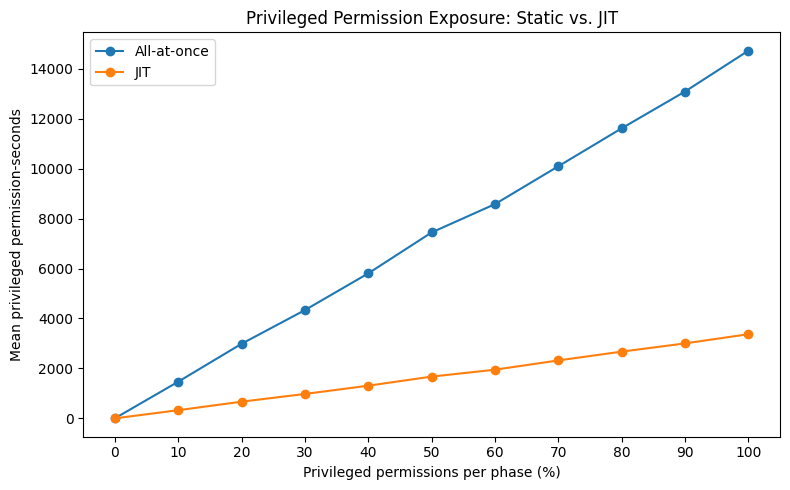

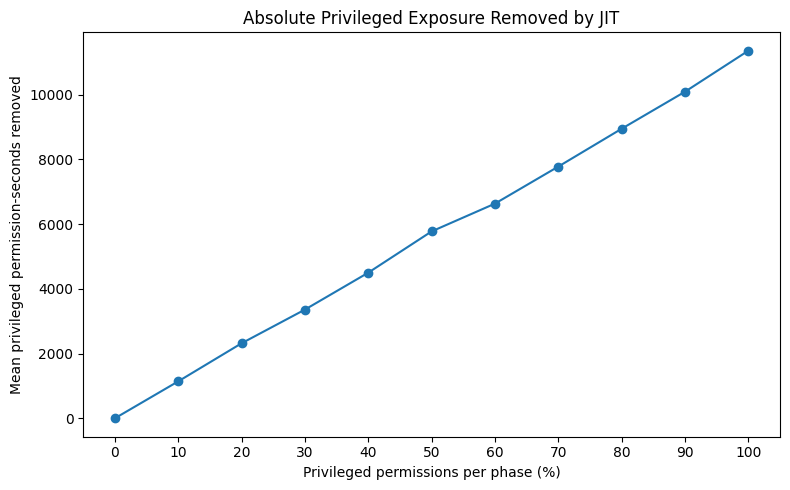

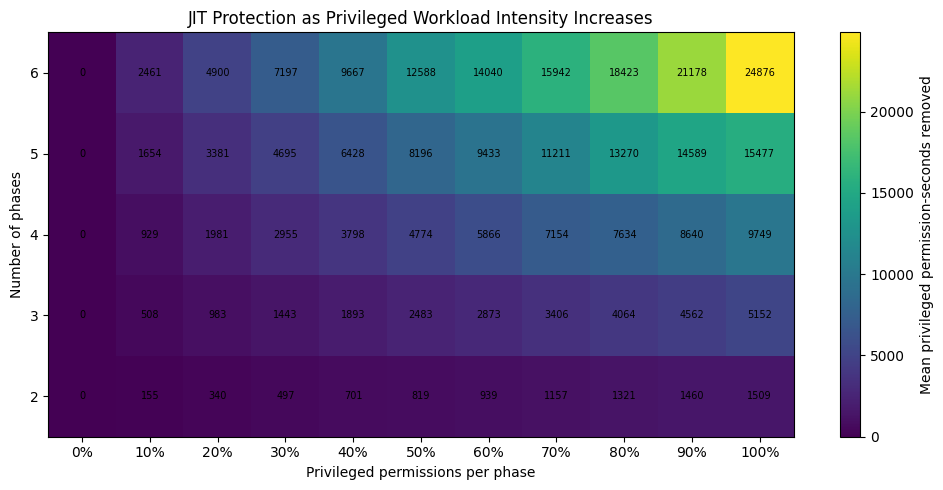

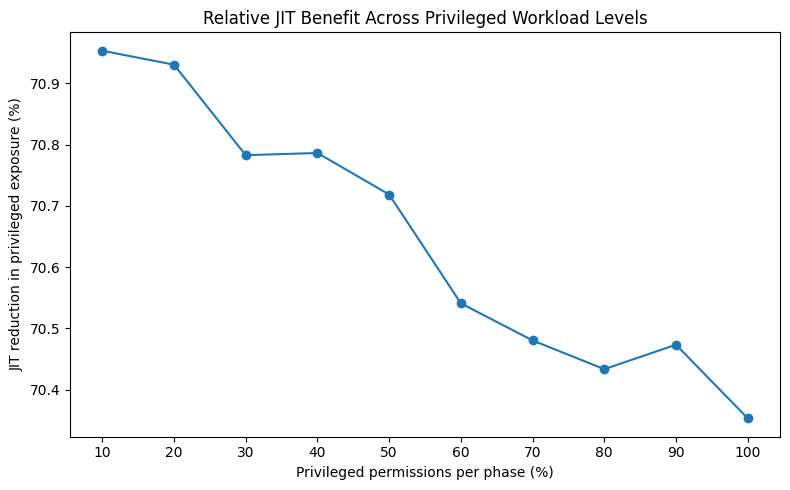


0% PRIVILEGED CONDITION


,target_privileged_pct,workflows,static_privileged_peak_mean,jit_privileged_peak_mean,privileged_peak_reduction_mean,static_privileged_permission_seconds_mean,jit_privileged_permission_seconds_mean,privileged_permission_seconds_removed_mean,privileged_time_reduction_mean,nonprivileged_time_reduction_mean,all_write_time_reduction_mean
0,0,500,0.0,0.0,NaN,0.0,0.0,0.0,NaN,59.4,59.4



50% PRIVILEGED CONDITION


,target_privileged_pct,workflows,static_privileged_peak_mean,jit_privileged_peak_mean,privileged_peak_reduction_mean,static_privileged_permission_seconds_mean,jit_privileged_permission_seconds_mean,privileged_permission_seconds_removed_mean,privileged_time_reduction_mean,nonprivileged_time_reduction_mean,all_write_time_reduction_mean
5,50,500,19.73,5.0,70.72,7443.51,1671.6,5771.91,70.72,65.61,68.47



100% PRIVILEGED CONDITION


,target_privileged_pct,workflows,static_privileged_peak_mean,jit_privileged_peak_mean,privileged_peak_reduction_mean,static_privileged_permission_seconds_mean,jit_privileged_permission_seconds_mean,privileged_permission_seconds_removed_mean,privileged_time_reduction_mean,nonprivileged_time_reduction_mean,all_write_time_reduction_mean
10,100,500,38.76,10.0,70.35,14721.87,3369.3,11352.57,70.35,NaN,70.35


In [ ]:
privileged_summary_exp5 = (
    privileged_results_exp5
    .groupby(
        "target_privileged_pct",
        as_index=False
    )
    .agg(
        workflows=(
            "workflow_id",
            "count"
        ),

        static_privileged_peak_mean=(
            "static_privileged_peak",
            "mean"
        ),

        jit_privileged_peak_mean=(
            "jit_privileged_peak",
            "mean"
        ),

        privileged_peak_reduction_mean=(
            "privileged_peak_reduction_pct",
            "mean"
        ),

        static_privileged_permission_seconds_mean=(
            "static_privileged_permission_seconds",
            "mean"
        ),

        jit_privileged_permission_seconds_mean=(
            "jit_privileged_permission_seconds",
            "mean"
        ),

        privileged_permission_seconds_removed_mean=(
            "privileged_permission_seconds_removed",
            "mean"
        ),

        privileged_time_reduction_mean=(
            "privileged_time_reduction_pct",
            "mean"
        ),

        nonprivileged_time_reduction_mean=(
            "nonprivileged_time_reduction_pct",
            "mean"
        ),

        all_write_time_reduction_mean=(
            "all_write_time_reduction_pct",
            "mean"
        )
    )
)


privileged_phase_summary_exp5 = (
    privileged_results_exp5
    .groupby(
        [
            "phase_count",
            "target_privileged_pct"
        ],
        as_index=False
    )
    .agg(
        static_privileged_permission_seconds_mean=(
            "static_privileged_permission_seconds",
            "mean"
        ),

        jit_privileged_permission_seconds_mean=(
            "jit_privileged_permission_seconds",
            "mean"
        ),

        privileged_permission_seconds_removed_mean=(
            "privileged_permission_seconds_removed",
            "mean"
        ),

        privileged_time_reduction_mean=(
            "privileged_time_reduction_pct",
            "mean"
        ),

        privileged_peak_reduction_mean=(
            "privileged_peak_reduction_pct",
            "mean"
        )
    )
)


privileged_results_exp5.to_csv(
    "exp5_privileged_percentage_raw.csv",
    index=False
)

privileged_summary_exp5.to_csv(
    "exp5_privileged_percentage_summary.csv",
    index=False
)

privileged_phase_summary_exp5.to_csv(
    "exp5_privileged_percentage_by_phase.csv",
    index=False
)


print(
    "\nPRIVILEGED-PERMISSION RESULTS"
)

display(
    privileged_summary_exp5.round(
        2
    )
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    privileged_summary_exp5[
        "target_privileged_pct"
    ],
    privileged_summary_exp5[
        "static_privileged_permission_seconds_mean"
    ],
    marker="o",
    label="All-at-once"
)

plt.plot(
    privileged_summary_exp5[
        "target_privileged_pct"
    ],
    privileged_summary_exp5[
        "jit_privileged_permission_seconds_mean"
    ],
    marker="o",
    label="JIT"
)

plt.xlabel(
    "Privileged permissions per phase (%)"
)

plt.ylabel(
    "Mean privileged permission-seconds"
)

plt.title(
    "Privileged Permission Exposure: Static vs. JIT"
)

plt.xticks(
    PRIVILEGED_PERCENTAGES
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "exp5_privileged_static_vs_jit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exp5_privileged_static_vs_jit.pdf",
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    privileged_summary_exp5[
        "target_privileged_pct"
    ],
    privileged_summary_exp5[
        "privileged_permission_seconds_removed_mean"
    ],
    marker="o"
)

plt.xlabel(
    "Privileged permissions per phase (%)"
)

plt.ylabel(
    "Mean privileged permission-seconds removed"
)

plt.title(
    "Absolute Privileged Exposure Removed by JIT"
)

plt.xticks(
    PRIVILEGED_PERCENTAGES
)

plt.tight_layout()

plt.savefig(
    "exp5_privileged_exposure_removed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exp5_privileged_exposure_removed.pdf",
    bbox_inches="tight"
)

plt.show()


privileged_heatmap = (
    privileged_phase_summary_exp5
    .pivot(
        index="phase_count",
        columns="target_privileged_pct",
        values="privileged_permission_seconds_removed_mean"
    )
)


plt.figure(
    figsize=(10, 5)
)

image = plt.imshow(
    privileged_heatmap.values,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    image,
    label="Mean privileged permission-seconds removed"
)

plt.xticks(
    range(
        len(
            privileged_heatmap.columns
        )
    ),
    [
        f"{int(x)}%"
        for x
        in privileged_heatmap.columns
    ]
)

plt.yticks(
    range(
        len(
            privileged_heatmap.index
        )
    ),
    [
        str(
            int(x)
        )
        for x
        in privileged_heatmap.index
    ]
)

plt.xlabel(
    "Privileged permissions per phase"
)

plt.ylabel(
    "Number of phases"
)

plt.title(
    "JIT Protection as Privileged Workload Intensity Increases"
)


for i in range(
    privileged_heatmap.shape[0]
):

    for j in range(
        privileged_heatmap.shape[1]
    ):

        value = (
            privileged_heatmap
            .iloc[i, j]
        )

        plt.text(
            j,
            i,
            f"{value:.0f}",
            ha="center",
            va="center",
            fontsize=7
        )


plt.tight_layout()

plt.savefig(
    "exp5_privileged_phase_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exp5_privileged_phase_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()


nonzero_privileged = (
    privileged_summary_exp5[
        privileged_summary_exp5[
            "target_privileged_pct"
        ] > 0
    ]
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    nonzero_privileged[
        "target_privileged_pct"
    ],
    nonzero_privileged[
        "privileged_time_reduction_mean"
    ],
    marker="o"
)

plt.xlabel(
    "Privileged permissions per phase (%)"
)

plt.ylabel(
    "JIT reduction in privileged exposure (%)"
)

plt.title(
    "Relative JIT Benefit Across Privileged Workload Levels"
)

plt.xticks(
    list(
        range(
            10,
            101,
            10
        )
    )
)

plt.tight_layout()

plt.savefig(
    "exp5_privileged_relative_reduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exp5_privileged_relative_reduction.pdf",
    bbox_inches="tight"
)

plt.show()


print(
    "\n0% PRIVILEGED CONDITION"
)

display(
    privileged_summary_exp5[
        privileged_summary_exp5[
            "target_privileged_pct"
        ] == 0
    ].round(
        2
    )
)


print(
    "\n50% PRIVILEGED CONDITION"
)

display(
    privileged_summary_exp5[
        privileged_summary_exp5[
            "target_privileged_pct"
        ] == 50
    ].round(
        2
    )
)


print(
    "\n100% PRIVILEGED CONDITION"
)

display(
    privileged_summary_exp5[
        privileged_summary_exp5[
            "target_privileged_pct"
        ] == 100
    ].round(
        2
    )
)

In [ ]:
FAILURE_RATES = [
    0.00,
    0.01,
    0.05,
    0.10,
    0.25
]

TTL_VALUES = [
    None,
    180,
    300,
    600
]


def next_required_time(
    permission,
    transition_index,
    phase_sets,
    phase_starts,
    workflow_end
):

    for j in range(
        transition_index + 1,
        len(
            phase_sets
        )
    ):

        if permission in phase_sets[j]:

            return phase_starts[j]

    return workflow_end


fault_rows = []


for workflow in workflows:

    phase_sets = workflow[
        "phase_sets"
    ]

    durations = workflow[
        "durations"
    ]

    phase_starts = [
        0
    ]

    for duration in durations[:-1]:

        phase_starts.append(
            phase_starts[-1]
            + duration
        )

    phase_ends = [
        phase_starts[i]
        + durations[i]
        for i in range(
            len(
                durations
            )
        )
    ]

    workflow_end = sum(
        durations
    )


    for failure_rate in FAILURE_RATES:

        local_rng = (
            np.random.default_rng(
                SEED
                + workflow[
                    "workflow_id"
                ] * 10000
                + int(
                    failure_rate
                    * 1000
                )
            )
        )

        transition_failures = [
            (
                local_rng.random()
                < failure_rate
            )
            for _ in range(
                len(
                    phase_sets
                ) - 1
            )
        ]


        for ttl in TTL_VALUES:

            stale_permission_seconds = 0.0

            stale_risk_seconds = 0.0

            failed_transition_count = 0


            for i in range(
                len(
                    phase_sets
                ) - 1
            ):

                if not transition_failures[i]:
                    continue

                failed_transition_count += 1

                stale_permissions = (
                    phase_sets[i]
                    - phase_sets[
                        i + 1
                    ]
                )

                stale_start = (
                    phase_ends[i]
                )

                grant_time = (
                    phase_starts[i]
                )


                for permission in stale_permissions:

                    reactivation_time = (
                        next_required_time(
                            permission,
                            i,
                            phase_sets,
                            phase_starts,
                            workflow_end
                        )
                    )

                    if ttl is None:

                        stale_end = min(
                            workflow_end,
                            reactivation_time
                        )

                    else:

                        expiration = (
                            grant_time
                            + ttl
                        )

                        stale_end = min(
                            workflow_end,
                            reactivation_time,
                            expiration
                        )


                    stale_duration = max(
                        0,
                        stale_end
                        - stale_start
                    )

                    stale_permission_seconds += (
                        stale_duration
                    )

                    stale_risk_seconds += (
                        stale_duration
                        * risk_weight(
                            permission
                        )
                    )


            fault_rows.append(
                {
                    "workflow_id":
                        workflow[
                            "workflow_id"
                        ],

                    "principal":
                        workflow[
                            "principal"
                        ],

                    "phase_count":
                        workflow[
                            "phase_count"
                        ],

                    "retention_regime":
                        workflow[
                            "retention_regime"
                        ],

                    "failure_rate":
                        failure_rate,

                    "ttl_seconds":
                        (
                            -1
                            if ttl is None
                            else ttl
                        ),

                    "ttl_label":
                        (
                            "No TTL"
                            if ttl is None
                            else f"{ttl}s"
                        ),

                    "failed_transitions":
                        failed_transition_count,

                    "stale_permission_seconds":
                        stale_permission_seconds,

                    "stale_risk_weighted_seconds":
                        stale_risk_seconds
                }
            )


fault_results_exp5 = pd.DataFrame(
    fault_rows
)


fault_principal_exp5 = (
    fault_results_exp5
    .groupby(
        [
            "principal",
            "failure_rate",
            "ttl_seconds",
            "ttl_label"
        ],
        as_index=False
    )
    .agg(
        stale_permission_seconds=(
            "stale_permission_seconds",
            "mean"
        ),

        stale_risk_weighted_seconds=(
            "stale_risk_weighted_seconds",
            "mean"
        ),

        failed_transitions=(
            "failed_transitions",
            "mean"
        )
    )
)


fault_summary_exp5 = (
    fault_principal_exp5
    .groupby(
        [
            "failure_rate",
            "ttl_seconds",
            "ttl_label"
        ],
        as_index=False
    )
    .agg(
        stale_permission_seconds_mean=(
            "stale_permission_seconds",
            "mean"
        ),

        stale_permission_seconds_sd=(
            "stale_permission_seconds",
            "std"
        ),

        stale_risk_seconds_mean=(
            "stale_risk_weighted_seconds",
            "mean"
        ),

        stale_risk_seconds_sd=(
            "stale_risk_weighted_seconds",
            "std"
        )
    )
)


baseline = (
    fault_summary_exp5[
        fault_summary_exp5[
            "ttl_seconds"
        ] == -1
    ][
        [
            "failure_rate",
            "stale_permission_seconds_mean",
            "stale_risk_seconds_mean"
        ]
    ]
    .rename(
        columns={
            "stale_permission_seconds_mean":
                "baseline_permission_seconds",

            "stale_risk_seconds_mean":
                "baseline_risk_seconds"
        }
    )
)


fault_summary_exp5 = (
    fault_summary_exp5
    .merge(
        baseline,
        on="failure_rate",
        how="left"
    )
)


fault_summary_exp5[
    "permission_exposure_reduction_pct"
] = np.where(

    fault_summary_exp5[
        "baseline_permission_seconds"
    ] > 0,

    100
    * (
        fault_summary_exp5[
            "baseline_permission_seconds"
        ]
        -
        fault_summary_exp5[
            "stale_permission_seconds_mean"
        ]
    )
    /
    fault_summary_exp5[
        "baseline_permission_seconds"
    ],

    0
)


fault_summary_exp5[
    "risk_exposure_reduction_pct"
] = np.where(

    fault_summary_exp5[
        "baseline_risk_seconds"
    ] > 0,

    100
    * (
        fault_summary_exp5[
            "baseline_risk_seconds"
        ]
        -
        fault_summary_exp5[
            "stale_risk_seconds_mean"
        ]
    )
    /
    fault_summary_exp5[
        "baseline_risk_seconds"
    ],

    0
)


display(
    fault_summary_exp5.round(
        3
    )
)


print(
    "\n5-minute TTL at 10% injected failure:"
)

display(
    fault_summary_exp5[
        (
            fault_summary_exp5[
                "failure_rate"
            ] == 0.10
        )
        &
        (
            fault_summary_exp5[
                "ttl_seconds"
            ] == 300
        )
    ].round(
        3
    )
)

Coordinator pass rate: 100.0 %
Residual permissions: 0


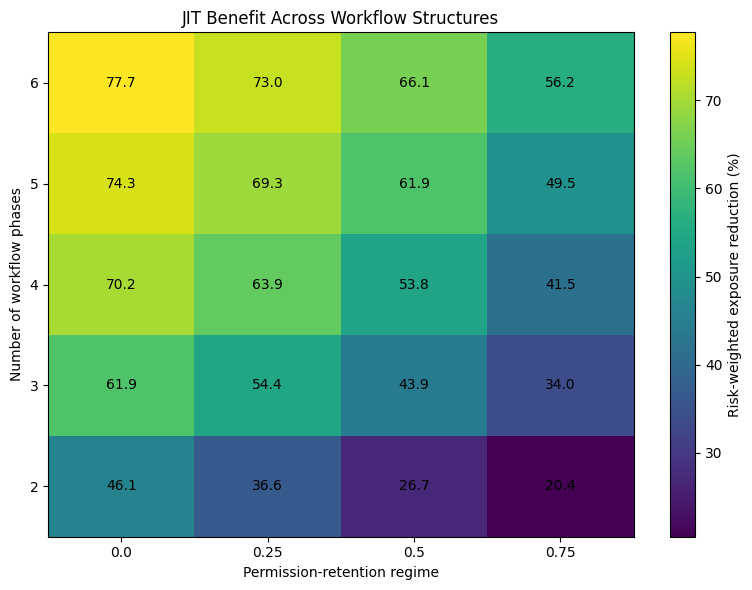

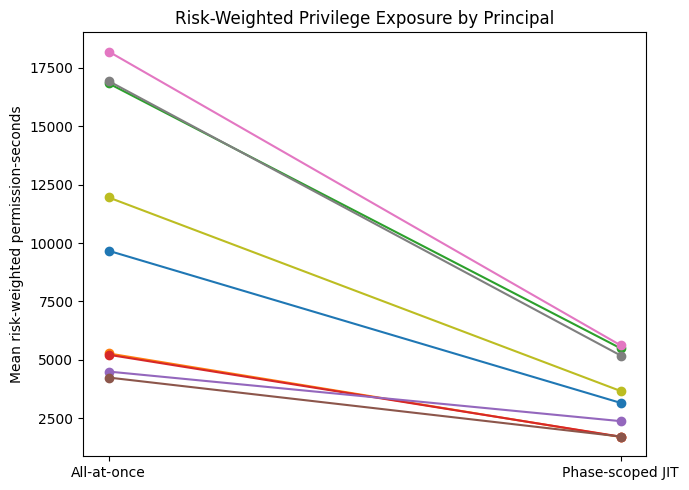

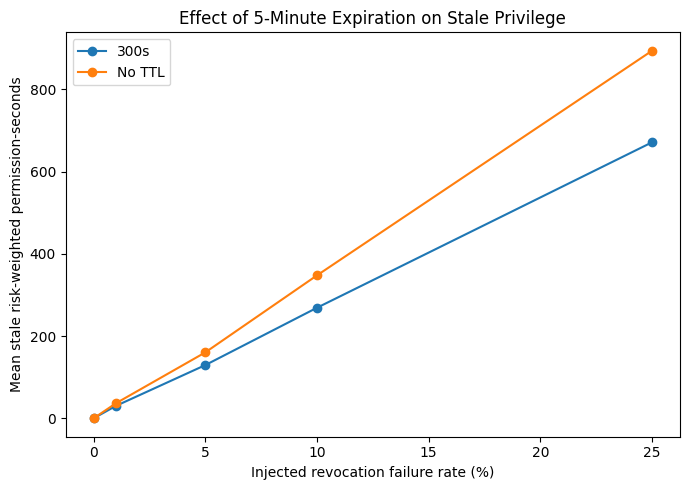

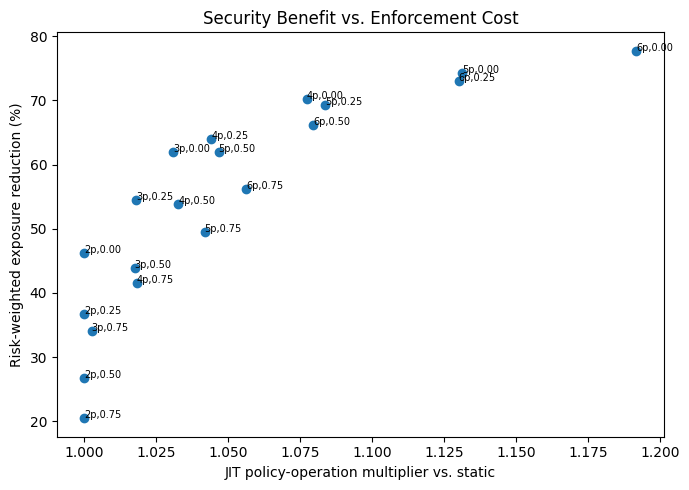


OVERALL RESULTS
Mean peak reduction: 38.71 %
Mean permission-time reduction: 54.09 %
Mean risk-weighted reduction: 54.09 %
Mean high-impact reduction: 54.08 %
Mean observed consecutive-phase overlap: 0.352
Mean JIT policy-operation multiplier: 1.05

PRINCIPAL-LEVEL STATISTICS


,metric,n_principals,static_mean,jit_mean,mean_reduction_pct,bootstrap_95_ci_low_pct,bootstrap_95_ci_high_pct,exact_signflip_p,wilcoxon_p,cohens_dz
0,Peak concurrent permissions,9,7.7220,3.9704,46.3127,39.7665,51.2017,0.0039,0.002,1.4361
1,Permission-time exposure,9,2797.3306,926.5333,64.8629,59.9800,68.3889,0.0039,0.002,1.5355
2,Risk-weighted permission-time,9,10309.7639,3406.3000,64.8585,59.9456,68.4018,0.0039,0.002,1.6401
3,High-impact permission-time,9,2504.1444,826.5889,64.8562,59.9332,68.4069,0.0039,0.002,1.6733



SENSITIVITY ANALYSIS


,phase_count,retention_regime,observed_overlap_mean,observed_overlap_sd,peak_reduction_mean,peak_reduction_sd,permission_time_reduction_mean,permission_time_reduction_sd,risk_time_reduction_mean,risk_time_reduction_sd,high_impact_reduction_mean,high_impact_reduction_sd,policy_operation_multiplier_mean
0,2,0.00,0.081,0.121,35.106,7.697,46.199,6.636,46.149,6.675,46.133,6.684,1.000
1,2,0.25,0.261,0.098,25.409,6.900,36.638,5.505,36.630,5.384,36.628,5.332,1.000
2,2,0.50,0.465,0.105,16.150,5.078,26.763,5.932,26.740,5.955,26.729,5.966,1.000
3,2,0.75,0.586,0.080,8.892,2.142,20.403,4.269,20.443,4.303,20.457,4.320,1.000
4,3,0.00,0.088,0.116,49.557,9.272,61.831,6.859,61.883,6.691,61.911,6.612,1.031
5,3,0.25,0.274,0.077,39.577,6.259,54.460,4.330,54.398,4.424,54.372,4.464,1.018
6,3,0.50,0.446,0.085,26.467,5.594,43.742,6.018,43.856,5.734,43.914,5.592,1.017
7,3,0.75,0.598,0.050,17.430,5.075,33.980,3.984,33.986,3.991,33.994,3.991,1.002
8,4,0.00,0.070,0.103,56.280,12.560,70.330,7.979,70.203,8.272,70.147,8.407,1.077
9,4,0.25,0.254,0.100,48.683,9.906,63.956,8.118,63.948,8.169,63.943,8.196,1.044



REVOCATION/TTL ANALYSIS


,failure_rate,ttl_seconds,ttl_label,stale_permission_seconds_mean,stale_permission_seconds_sd,stale_risk_seconds_mean,stale_risk_seconds_sd,baseline_permission_seconds,baseline_risk_seconds,permission_exposure_reduction_pct,risk_exposure_reduction_pct
0,0.00,-1,No TTL,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.00,180,180s,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.00,300,300s,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.00,600,600s,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.01,-1,No TTL,9.822,6.297,36.622,22.762,9.822,36.622,0.000,0.000
5,0.01,180,180s,4.378,2.753,16.386,9.637,9.822,36.622,55.430,55.256
6,0.01,300,300s,8.111,5.225,30.244,18.643,9.822,36.622,17.421,17.415
7,0.01,600,600s,9.783,6.300,36.467,22.756,9.822,36.622,0.396,0.425
8,0.05,-1,No TTL,43.364,21.357,160.289,75.605,43.364,160.289,0.000,0.000
9,0.05,180,180s,20.178,10.910,74.203,38.026,43.364,160.289,53.469,53.707


In [ ]:
class PhaseCoordinator:

    def __init__(self):

        self.active = set()

        self.grants = 0

        self.revocations = 0


    def transition(
        self,
        required
    ):

        required = set(
            required
        )

        revoke = (
            self.active
            - required
        )

        grant = (
            required
            - self.active
        )

        self.revocations += len(
            revoke
        )

        self.grants += len(
            grant
        )

        self.active -= revoke

        self.active |= grant

        return (
            self.active
            == required
        )


    def finish(self):

        self.revocations += len(
            self.active
        )

        self.active = set()

        return (
            len(
                self.active
            )
            == 0
        )


correctness_rows = []


for workflow in workflows:

    coordinator = (
        PhaseCoordinator()
    )

    passed = True


    for required in workflow[
        "phase_sets"
    ]:

        if not coordinator.transition(
            required
        ):

            passed = False


    if not coordinator.finish():

        passed = False


    correctness_rows.append(
        {
            "workflow_id":
                workflow[
                    "workflow_id"
                ],

            "principal":
                workflow[
                    "principal"
                ],

            "passed":
                passed,

            "grants":
                coordinator.grants,

            "revocations":
                coordinator.revocations,

            "residual_permissions":
                len(
                    coordinator.active
                )
        }
    )


correctness_exp5 = pd.DataFrame(
    correctness_rows
)


results_exp5_revised.to_csv(
    "exp5_revised_workflows.csv",
    index=False
)

principal_summary_exp5.to_csv(
    "exp5_revised_principal_summary.csv",
    index=False
)

statistics_exp5_revised.to_csv(
    "exp5_revised_statistics.csv",
    index=False
)

sensitivity_exp5.to_csv(
    "exp5_revised_sensitivity.csv",
    index=False
)

fault_results_exp5.to_csv(
    "exp5_revised_fault_raw.csv",
    index=False
)

fault_summary_exp5.to_csv(
    "exp5_revised_fault_summary.csv",
    index=False
)

correctness_exp5.to_csv(
    "exp5_revised_correctness.csv",
    index=False
)


print(
    "Coordinator pass rate:",
    round(
        100
        * correctness_exp5[
            "passed"
        ].mean(),
        2
    ),
    "%"
)

print(
    "Residual permissions:",
    correctness_exp5[
        "residual_permissions"
    ].sum()
)


heatmap_data = (
    sensitivity_exp5
    .pivot(
        index="phase_count",
        columns="retention_regime",
        values="risk_time_reduction_mean"
    )
)


plt.figure(
    figsize=(8, 6)
)

image = plt.imshow(
    heatmap_data.values,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    image,
    label="Risk-weighted exposure reduction (%)"
)

plt.xticks(
    range(
        len(
            heatmap_data.columns
        )
    ),
    [
        str(x)
        for x in heatmap_data.columns
    ]
)

plt.yticks(
    range(
        len(
            heatmap_data.index
        )
    ),
    [
        str(x)
        for x in heatmap_data.index
    ]
)

plt.xlabel(
    "Permission-retention regime"
)

plt.ylabel(
    "Number of workflow phases"
)

plt.title(
    "JIT Benefit Across Workflow Structures"
)


for i in range(
    heatmap_data.shape[0]
):

    for j in range(
        heatmap_data.shape[1]
    ):

        value = (
            heatmap_data
            .iloc[i, j]
        )

        plt.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center"
        )


plt.tight_layout()

plt.savefig(
    "exp5_sensitivity_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exp5_sensitivity_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(7, 5)
)


for _, row in (
    principal_summary_exp5
    .iterrows()
):

    plt.plot(
        [0, 1],
        [
            row[
                "static_risk_weighted_seconds"
            ],
            row[
                "jit_risk_weighted_seconds"
            ]
        ],
        marker="o"
    )


plt.xticks(
    [0, 1],
    [
        "All-at-once",
        "Phase-scoped JIT"
    ]
)

plt.ylabel(
    "Mean risk-weighted permission-seconds"
)

plt.title(
    "Risk-Weighted Privilege Exposure by Principal"
)

plt.tight_layout()

plt.savefig(
    "exp5_principal_risk_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exp5_principal_risk_comparison.pdf",
    bbox_inches="tight"
)

plt.show()


ttl_plot = (
    fault_summary_exp5[
        fault_summary_exp5[
            "ttl_seconds"
        ].isin(
            [-1, 300]
        )
    ]
    .copy()
)


plt.figure(
    figsize=(7, 5)
)


for ttl_label, group in ttl_plot.groupby(
    "ttl_label"
):

    group = group.sort_values(
        "failure_rate"
    )

    plt.plot(
        group[
            "failure_rate"
        ] * 100,
        group[
            "stale_risk_seconds_mean"
        ],
        marker="o",
        label=ttl_label
    )


plt.xlabel(
    "Injected revocation failure rate (%)"
)

plt.ylabel(
    "Mean stale risk-weighted permission-seconds"
)

plt.title(
    "Effect of 5-Minute Expiration on Stale Privilege"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "exp5_ttl_risk_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exp5_ttl_risk_sensitivity.pdf",
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    sensitivity_exp5[
        "policy_operation_multiplier_mean"
    ],
    sensitivity_exp5[
        "risk_time_reduction_mean"
    ]
)

for _, row in (
    sensitivity_exp5
    .iterrows()
):

    plt.annotate(
        (
            f"{int(row['phase_count'])}p,"
            f"{row['retention_regime']:.2f}"
        ),
        (
            row[
                "policy_operation_multiplier_mean"
            ],
            row[
                "risk_time_reduction_mean"
            ]
        ),
        fontsize=7
    )


plt.xlabel(
    "JIT policy-operation multiplier vs. static"
)

plt.ylabel(
    "Risk-weighted exposure reduction (%)"
)

plt.title(
    "Security Benefit vs. Enforcement Cost"
)

plt.tight_layout()

plt.savefig(
    "exp5_security_cost_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "exp5_security_cost_tradeoff.pdf",
    bbox_inches="tight"
)

plt.show()


print(
    "\nOVERALL RESULTS"
)

print(
    "Mean peak reduction:",
    round(
        results_exp5_revised[
            "peak_reduction_pct"
        ].mean(),
        2
    ),
    "%"
)

print(
    "Mean permission-time reduction:",
    round(
        results_exp5_revised[
            "permission_time_reduction_pct"
        ].mean(),
        2
    ),
    "%"
)

print(
    "Mean risk-weighted reduction:",
    round(
        results_exp5_revised[
            "risk_time_reduction_pct"
        ].mean(),
        2
    ),
    "%"
)

print(
    "Mean high-impact reduction:",
    round(
        results_exp5_revised[
            "high_impact_reduction_pct"
        ].mean(),
        2
    ),
    "%"
)

print(
    "Mean observed consecutive-phase overlap:",
    round(
        results_exp5_revised[
            "observed_overlap"
        ].mean(),
        3
    )
)

print(
    "Mean JIT policy-operation multiplier:",
    round(
        results_exp5_revised[
            "policy_operation_multiplier"
        ].mean(),
        2
    )
)

print(
    "\nPRINCIPAL-LEVEL STATISTICS"
)

display(
    statistics_exp5_revised.round(
        4
    )
)

print(
    "\nSENSITIVITY ANALYSIS"
)

display(
    sensitivity_exp5.round(
        3
    )
)

print(
    "\nREVOCATION/TTL ANALYSIS"
)

display(
    fault_summary_exp5.round(
        3
    )
)

#Runtime Governance

Checks an agent’s requested action and decides whether to allow or deny it.

In [ ]:
def governance_check(agent, requested_permission, resource, mapped_policies):
    for policy in mapped_policies:
        if policy["identity"] == agent:

            for denied in policy["denied_permissions"]:
                if (
                    denied["permission"] == requested_permission
                    and denied["resource"] == resource
                ):
                    return {
                        "decision": "DENY",
                        "reason": "Permission blocked by policy"
                    }

            for allowed in policy["allowed_permissions"]:
                if (
                    allowed["permission"] == requested_permission
                    and allowed["resource"] == resource
                ):
                    return {
                        "decision": "ALLOW",
                        "reason": "Permission approved by policy"
                    }

    return {
        "decision": "DENY",
        "reason": "Agent or permission not registered"
    }


tool_call = {
    "agent": "Database_Agent",
    "permission": "Owns",
    "resource": "USERS@GHOST.CORP"
}

result = governance_check(
    tool_call["agent"],
    tool_call["permission"],
    tool_call["resource"],
    mapped_policies
)

print(result)

{'decision': 'DENY', 'reason': 'Permission blocked by policy'}


#Governance Log + Alert

Saves the decision and sends an alert when the system blocks an action.

In [ ]:
governance_log = []

def log_governance_decision(tool_call, decision):
    log_entry = {
        "agent": tool_call["agent"],
        "permission": tool_call["permission"],
        "resource": tool_call["resource"],
        "decision": decision["decision"],
        "reason": decision["reason"]
    }

    governance_log.append(log_entry)

    if decision["decision"] == "DENY":
        print("ALERT: blocked unauthorized agent action")
        print(json.dumps(log_entry, indent=2))
    else:
        print("Action allowed")
        print(json.dumps(log_entry, indent=2))


log_governance_decision(tool_call, result)

ALERT: blocked unauthorized agent action
{
  "agent": "Database_Agent",
  "permission": "Owns",
  "resource": "USERS@GHOST.CORP",
  "decision": "DENY",
  "reason": "Permission blocked by policy"
}


#Figures 1-6

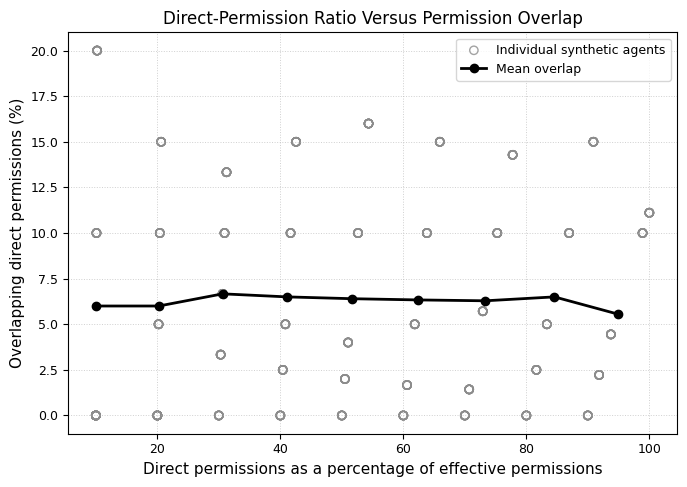

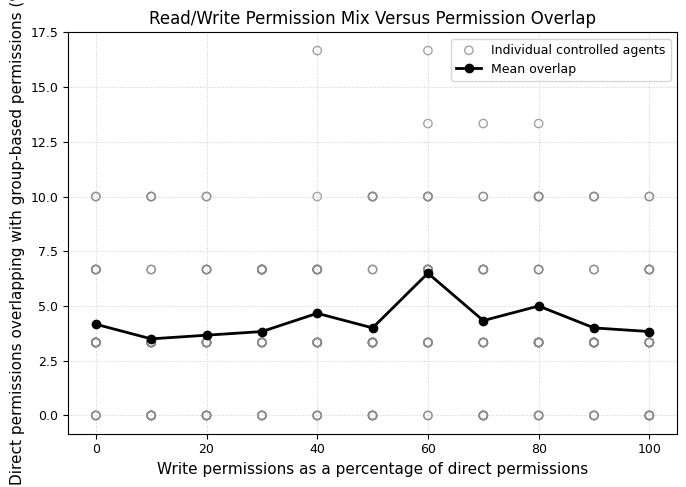

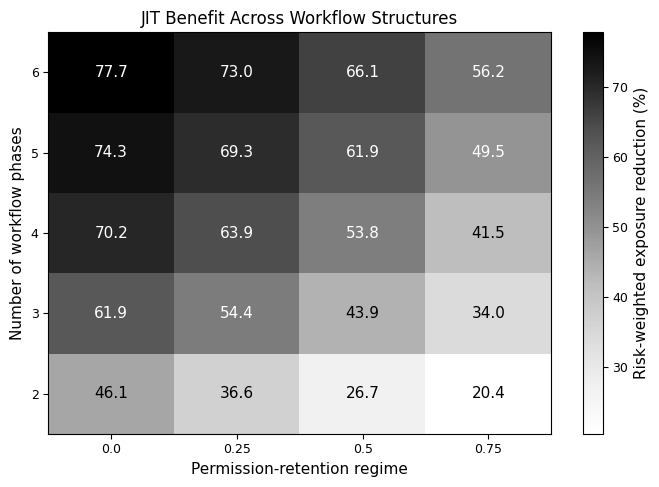

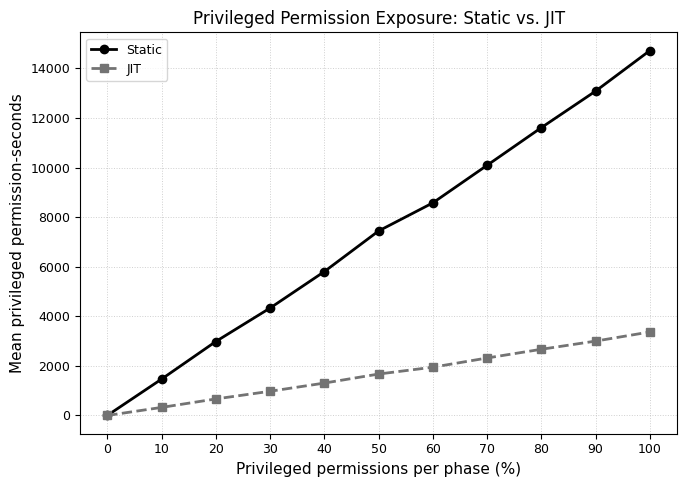

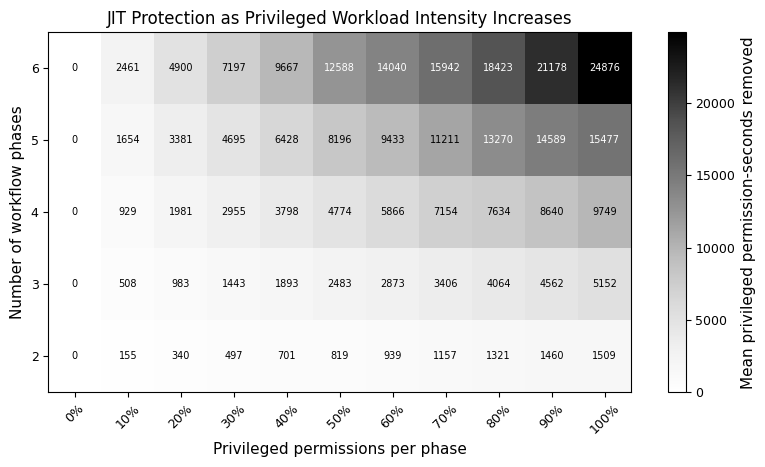

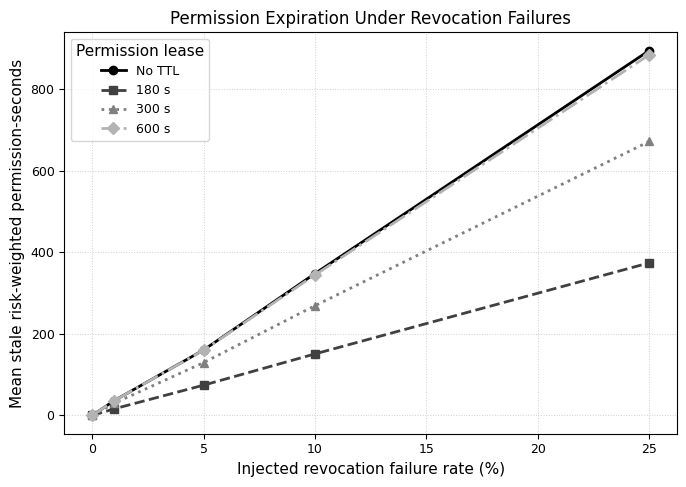

FINAL PAPER FIGURES GENERATED
Figure 1: figure1_direct_permission_overlap.pdf
Figure 2: figure2_read_write_overlap.pdf
Figure 3: figure3_jit_workflow_structure.pdf
Figure 4: figure4_privileged_static_vs_jit.pdf
Figure 5: figure5_privileged_workload_heatmap.pdf
Figure 6: figure6_ttl_revocation_failure.pdf


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

direct_summary_plot = experiment_1_summary.sort_values(
    "mean_actual_direct_ratio"
)

plt.figure(figsize=(7, 5))

plt.scatter(
    experiment_1_df["actual_direct_ratio"] * 100,
    experiment_1_df["overlap_rate"] * 100,
    facecolors="none",
    edgecolors="0.55",
    alpha=0.8,
    label="Individual synthetic agents"
)

plt.plot(
    direct_summary_plot["mean_actual_direct_ratio"] * 100,
    direct_summary_plot["mean_overlap_rate"] * 100,
    color="black",
    marker="o",
    linewidth=2,
    label="Mean overlap"
)

plt.xlabel("Direct permissions as a percentage of effective permissions")
plt.ylabel("Overlapping direct permissions (%)")
plt.title("Direct-Permission Ratio Versus Permission Overlap")
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("figure1_direct_permission_overlap.png", dpi=300, bbox_inches="tight")
plt.savefig("figure1_direct_permission_overlap.pdf", bbox_inches="tight")
plt.show()


read_write_summary_plot = read_write_summary.sort_values(
    "mean_actual_write_ratio"
)

plt.figure(figsize=(7, 5))

plt.scatter(
    read_write_valid_df["actual_write_ratio"] * 100,
    read_write_valid_df["overlap_rate"] * 100,
    facecolors="none",
    edgecolors="0.55",
    alpha=0.8,
    label="Individual controlled agents"
)

plt.plot(
    read_write_summary_plot["mean_actual_write_ratio"] * 100,
    read_write_summary_plot["mean_overlap_rate"] * 100,
    color="black",
    marker="o",
    linewidth=2,
    label="Mean overlap"
)

plt.xlabel("Write permissions as a percentage of direct permissions")
plt.ylabel("Direct permissions overlapping with group-based permissions (%)")
plt.title("Read/Write Permission Mix Versus Permission Overlap")
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("figure2_read_write_overlap.png", dpi=300, bbox_inches="tight")
plt.savefig("figure2_read_write_overlap.pdf", bbox_inches="tight")
plt.show()


heatmap_data_final = (
    sensitivity_exp5
    .pivot(
        index="phase_count",
        columns="retention_regime",
        values="risk_time_reduction_mean"
    )
    .sort_index()
)

plt.figure(figsize=(7, 5))

img = plt.imshow(
    heatmap_data_final.values,
    aspect="auto",
    origin="lower",
    cmap="Greys"
)

plt.colorbar(
    img,
    label="Risk-weighted exposure reduction (%)"
)

plt.xticks(
    range(len(heatmap_data_final.columns)),
    [str(x) for x in heatmap_data_final.columns]
)

plt.yticks(
    range(len(heatmap_data_final.index)),
    [str(int(x)) for x in heatmap_data_final.index]
)

plt.xlabel("Permission-retention regime")
plt.ylabel("Number of workflow phases")
plt.title("JIT Benefit Across Workflow Structures")

threshold = (
    np.nanmin(heatmap_data_final.values)
    + np.nanmax(heatmap_data_final.values)
) / 2

for i in range(heatmap_data_final.shape[0]):
    for j in range(heatmap_data_final.shape[1]):
        value = heatmap_data_final.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="white" if value > threshold else "black"
        )

plt.tight_layout()
plt.savefig("figure3_jit_workflow_structure.png", dpi=300, bbox_inches="tight")
plt.savefig("figure3_jit_workflow_structure.pdf", bbox_inches="tight")
plt.show()


privileged_summary_final = privileged_summary_exp5.sort_values(
    "target_privileged_pct"
)

plt.figure(figsize=(7, 5))

plt.plot(
    privileged_summary_final["target_privileged_pct"],
    privileged_summary_final[
        "static_privileged_permission_seconds_mean"
    ],
    color="black",
    linestyle="-",
    marker="o",
    linewidth=2,
    label="Static"
)

plt.plot(
    privileged_summary_final["target_privileged_pct"],
    privileged_summary_final[
        "jit_privileged_permission_seconds_mean"
    ],
    color="0.45",
    linestyle="--",
    marker="s",
    linewidth=2,
    label="JIT"
)

plt.xlabel("Privileged permissions per phase (%)")
plt.ylabel("Mean privileged permission-seconds")
plt.title("Privileged Permission Exposure: Static vs. JIT")
plt.xticks(PRIVILEGED_PERCENTAGES)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("figure4_privileged_static_vs_jit.png", dpi=300, bbox_inches="tight")
plt.savefig("figure4_privileged_static_vs_jit.pdf", bbox_inches="tight")
plt.show()


privileged_heatmap_final = (
    privileged_phase_summary_exp5
    .pivot(
        index="phase_count",
        columns="target_privileged_pct",
        values="privileged_permission_seconds_removed_mean"
    )
    .sort_index()
)

plt.figure(figsize=(8, 4.8))

img = plt.imshow(
    privileged_heatmap_final.values,
    aspect="auto",
    origin="lower",
    cmap="Greys"
)

plt.colorbar(
    img,
    label="Mean privileged permission-seconds removed"
)

plt.xticks(
    range(len(privileged_heatmap_final.columns)),
    [
        f"{int(x)}%"
        for x in privileged_heatmap_final.columns
    ],
    rotation=45
)

plt.yticks(
    range(len(privileged_heatmap_final.index)),
    [
        str(int(x))
        for x in privileged_heatmap_final.index
    ]
)

plt.xlabel("Privileged permissions per phase")
plt.ylabel("Number of workflow phases")
plt.title("JIT Protection as Privileged Workload Intensity Increases")

threshold = (
    np.nanmin(privileged_heatmap_final.values)
    + np.nanmax(privileged_heatmap_final.values)
) / 2

for i in range(privileged_heatmap_final.shape[0]):
    for j in range(privileged_heatmap_final.shape[1]):
        value = privileged_heatmap_final.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.0f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if value > threshold else "black"
        )

plt.tight_layout()
plt.savefig("figure5_privileged_workload_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig("figure5_privileged_workload_heatmap.pdf", bbox_inches="tight")
plt.show()


ttl_plot_final = (
    fault_summary_exp5[
        fault_summary_exp5["ttl_seconds"].isin(
            [-1, 180, 300, 600]
        )
    ]
    .copy()
)

ttl_styles = {
    -1: {
        "label": "No TTL",
        "linestyle": "-",
        "marker": "o",
        "color": "black"
    },
    180: {
        "label": "180 s",
        "linestyle": "--",
        "marker": "s",
        "color": "0.25"
    },
    300: {
        "label": "300 s",
        "linestyle": ":",
        "marker": "^",
        "color": "0.50"
    },
    600: {
        "label": "600 s",
        "linestyle": "-.",
        "marker": "D",
        "color": "0.70"
    }
}

plt.figure(figsize=(7, 5))

for ttl in [-1, 180, 300, 600]:
    group = (
        ttl_plot_final[
            ttl_plot_final["ttl_seconds"] == ttl
        ]
        .sort_values("failure_rate")
    )

    style = ttl_styles[ttl]

    plt.plot(
        group["failure_rate"] * 100,
        group["stale_risk_seconds_mean"],
        label=style["label"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=6
    )

plt.xlabel("Injected revocation failure rate (%)")
plt.ylabel("Mean stale risk-weighted permission-seconds")
plt.title("Permission Expiration Under Revocation Failures")
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend(title="Permission lease")
plt.tight_layout()
plt.savefig("figure6_ttl_revocation_failure.png", dpi=300, bbox_inches="tight")
plt.savefig("figure6_ttl_revocation_failure.pdf", bbox_inches="tight")
plt.show()

print("FINAL PAPER FIGURES GENERATED")
print("Figure 1: figure1_direct_permission_overlap.pdf")
print("Figure 2: figure2_read_write_overlap.pdf")
print("Figure 3: figure3_jit_workflow_structure.pdf")
print("Figure 4: figure4_privileged_static_vs_jit.pdf")
print("Figure 5: figure5_privileged_workload_heatmap.pdf")
print("Figure 6: figure6_ttl_revocation_failure.pdf")